In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
# Download Apple stock data from Yahoo Finance (2010-2024)
df = yf.download('AAPL', start='2010-01-01', end='2024-12-31')

# Display the first few rows to inspect
df.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.440332,6.455078,6.391279,6.422878,493729600
2010-01-05,6.451465,6.487878,6.417459,6.458086,601904800
2010-01-06,6.348848,6.477047,6.342227,6.451467,552160000
2010-01-07,6.337110,6.379843,6.291067,6.372319,477131200
2010-01-08,6.379240,6.379842,6.291368,6.328683,447610800


In [ ]:
df['Date'] = pd.to_datetime(df.index)
df.set_index('Date', inplace=True)

# Check for missing data
df.isnull().sum()

# Normalize the 'Close' price for LSTM model
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [ ]:
def create_sequences(data, time_steps):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps, 0])
        y.append(data[i+time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 30  # Using past 60 days to predict the next day
X, y = create_sequences(scaled_data, time_steps)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape data for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Build LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0047
Epoch 2/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 9.5272e-05
Epoch 3/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 9.6533e-05
Epoch 4/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 8.4416e-05
Epoch 5/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 8.4688e-05
Epoch 6/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0183e-04
Epoch 7/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 9.2061e-05
Epoch 8/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 7.5851e-05
Epoch 9/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 7.0615e-05
Epoch 10/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 6.6861e-05
Epoch 11/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 7.1764e-05
Epoch 12/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 5.5103e-05
Epoch 13/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 5.2527e-05
Epoch 14/20
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 6.2506e-05
Epoch 15/20
94/94 ━

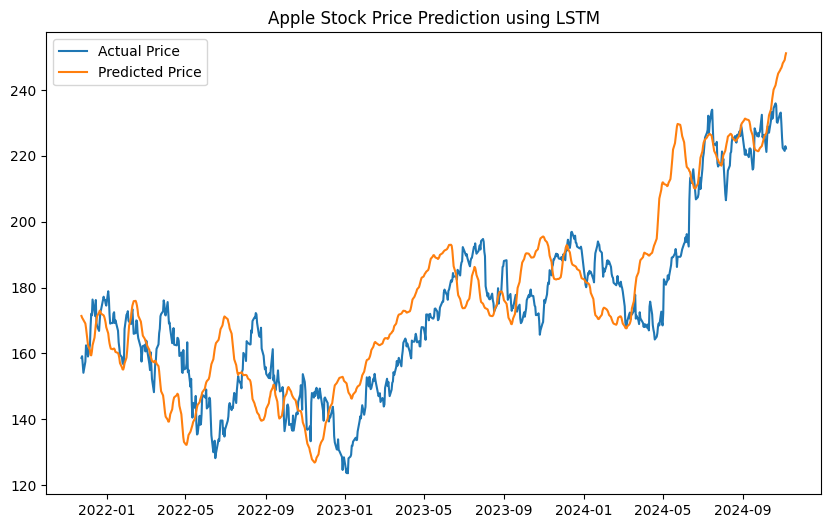

In [ ]:
# Ensure the length of predictions matches the test data
predictions = predictions.flatten()

# Plot predictions against actual stock prices for the test set
plt.figure(figsize=(10, 6))
plt.plot(df.index[train_size:train_size+len(predictions)], df['Close'][train_size:train_size+len(predictions)], label='Actual Price')
plt.plot(df.index[train_size:train_size+len(predictions)], predictions, label='Predicted Price')
plt.legend()
plt.title('Apple Stock Price Prediction using LSTM')
plt.show()


[*********************100%***********************]  1 of 1 completed

Epoch 1/50



/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1498
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0272
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0078
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0030
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025
Epoch 14/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024
Epoch 15/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024
Epoch 16/50
17/17 ━━━━━━━━━━━━

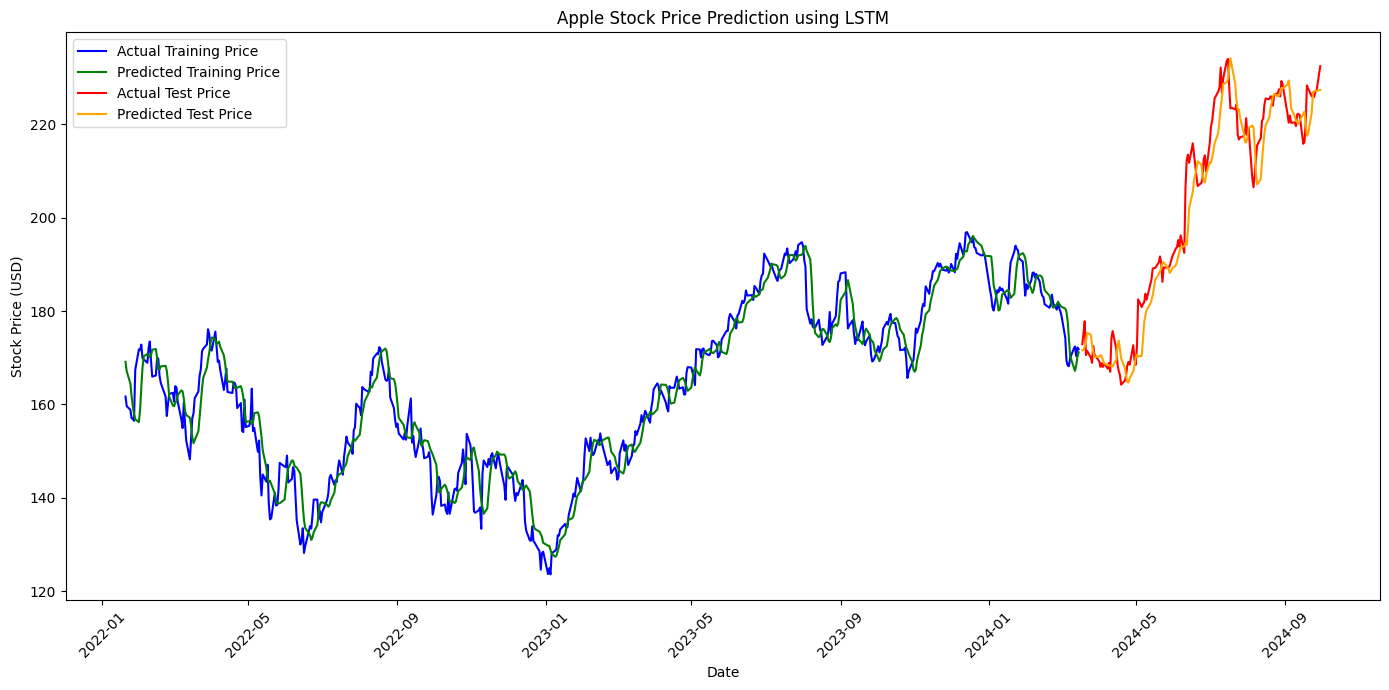

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2022-01-01', end='2024-10-01') # Adjusted end for better prediction window

# 2. Feature Engineering (Example: Lagged Features)
df['Close_lag_1'] = df['Close'].shift(1)
df['Close_lag_2'] = df['Close'].shift(2)
df.dropna(inplace=True)

# 3. Scale Data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close', 'Close_lag_1', 'Close_lag_2']]) # Scale features

# 4. Prepare Data for LSTM
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length), 1:] # input features
        y = data[i + seq_length, 0] # target (Close)
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 10 # Adjust sequence length as needed
X, y = create_sequences(scaled_data, seq_length)

# 5. Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 6. Build LSTM Model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 7. Train Model
model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

# 8. Make Predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# 9. Inverse Transform Predictions
train_predictions = scaler.inverse_transform(np.concatenate((train_predictions, np.zeros((len(train_predictions), 2))), axis=1))[:, 0]
y_train_actual = scaler.inverse_transform(np.concatenate((y_train.reshape(-1, 1), np.zeros((len(y_train), 2))), axis=1))[:, 0]
test_predictions = scaler.inverse_transform(np.concatenate((test_predictions, np.zeros((len(test_predictions), 2))), axis=1))[:, 0]
y_test_actual = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 2))), axis=1))[:, 0]

# 10. Plot Results
train_time = df.index[seq_length:train_size + seq_length]
test_time = df.index[train_size + seq_length:]

plt.figure(figsize=(14, 7))
plt.plot(train_time, y_train_actual, label='Actual Training Price', color='blue')
plt.plot(train_time, train_predictions, label='Predicted Training Price', color='green')
plt.plot(test_time, y_test_actual, label='Actual Test Price', color='red')
plt.plot(test_time, test_predictions, label='Predicted Test Price', color='orange')
plt.title('Apple Stock Price Prediction using LSTM')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index 

Test RMSE: 38.85449054398032


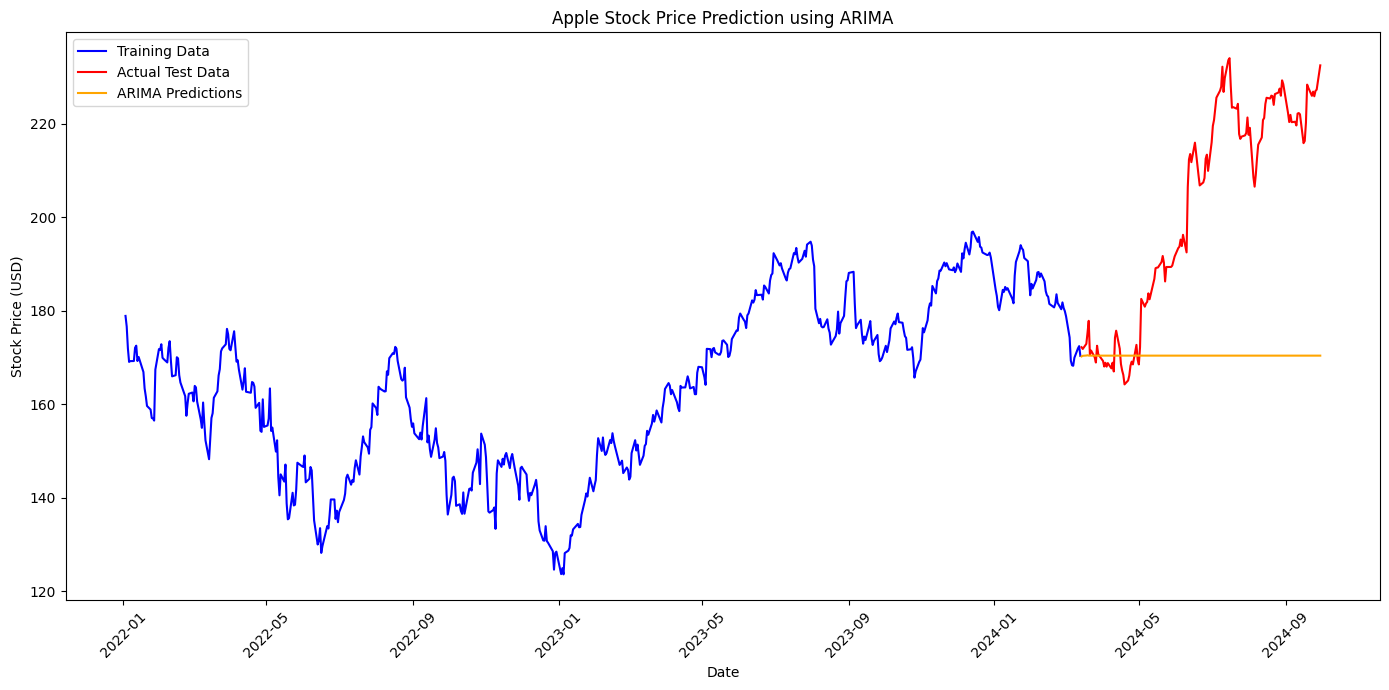

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2022-01-01', end='2024-10-01')

# 2. Prepare Data for ARIMA (Use Close Price)
data = df['Close']

# 3. Train-Test Split
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# 4. Fit ARIMA Model (p, d, q parameters need to be tuned)
# Example: ARIMA(5, 1, 0) - Adjust p, d, q based on your data analysis
model = ARIMA(train, order=(5, 1, 0))
model_fit = model.fit()

# 5. Make Predictions
predictions = model_fit.predict(start=len(train), end=len(data) - 1, typ='levels')

# 6. Evaluate Performance (RMSE)
rmse = sqrt(mean_squared_error(test, predictions))
print(f'Test RMSE: {rmse}')

# 7. Plot Results
plt.figure(figsize=(14, 7))
plt.plot(data.index[:train_size], train, label='Training Data', color='blue')
plt.plot(data.index[train_size:], test, label='Actual Test Data', color='red')
plt.plot(data.index[train_size:], predictions, label='ARIMA Predictions', color='orange')
plt.title('Apple Stock Price Prediction using ARIMA')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


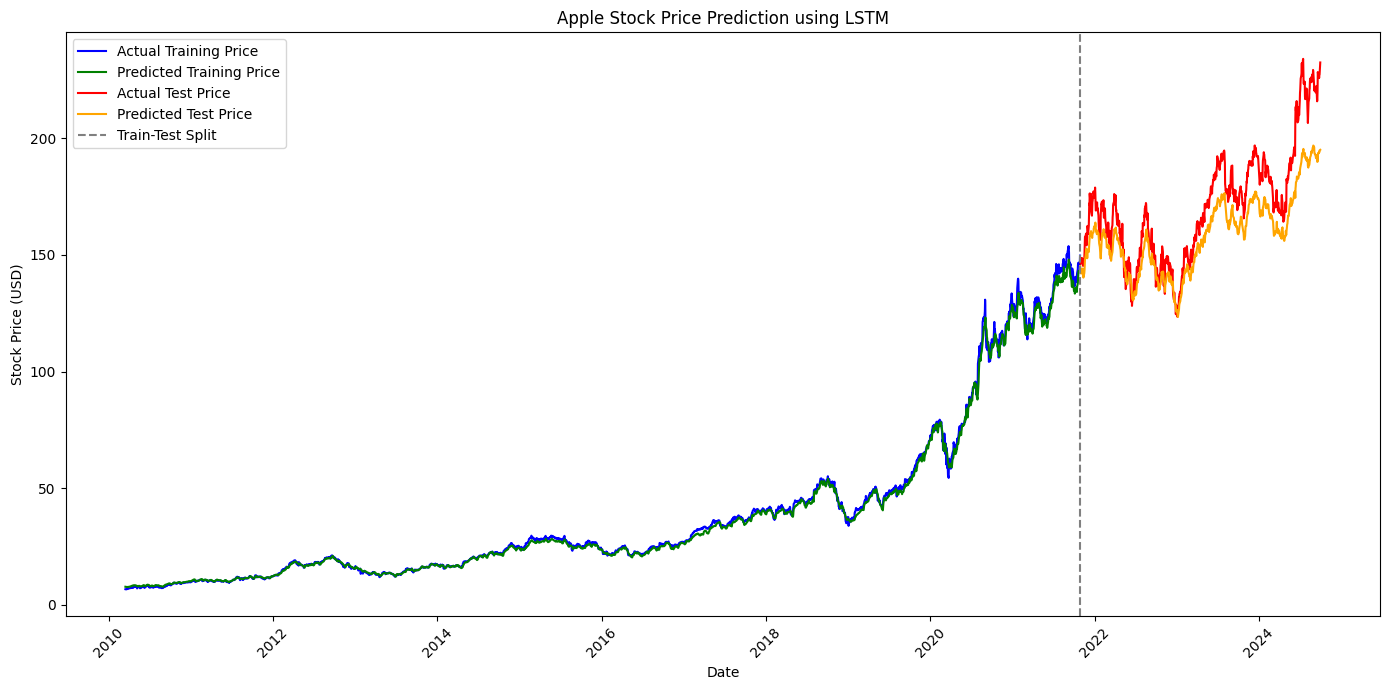

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2010-01-01', end='2024-10-01')

# 2. Calculate SMA using pandas
df['SMA_30'] = df['Close'].rolling(window=30).mean()

# 3. Calculate RSI using pandas and numpy
def calculate_rsi(data, window=14):
    delta = data.diff(1)
    delta = delta.dropna()
    up = delta.copy()
    down = delta.copy()
    up[up < 0] = 0
    down[down > 0] = 0
    roll_up1 = up.ewm(span=window, adjust=False).mean()
    roll_down1 = abs(down.ewm(span=window, adjust=False).mean())
    rs = roll_up1 / roll_down1
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi

df['RSI_14'] = calculate_rsi(df['Close'], window=14)

# 4. Lagged Features
df['Close_lag_1'] = df['Close'].shift(1)
df['Close_lag_2'] = df['Close'].shift(2)
df.dropna(inplace=True)

# 5. Scale Data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Close', 'SMA_30', 'RSI_14', 'Close_lag_1', 'Close_lag_2']])

# 6. Prepare Data for LSTM
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length), 1:]
        y = data[i + seq_length, 0]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

# 7. Train-Test Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 8. Build LSTM Model
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(100, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

# 9. Train Model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

# 10. Make Predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

# 11. Inverse Transform Predictions
train_predictions = scaler.inverse_transform(np.concatenate((train_predictions, np.zeros((len(train_predictions), 4))), axis=1))[:, 0]
y_train_actual = scaler.inverse_transform(np.concatenate((y_train.reshape(-1, 1), np.zeros((len(y_train), 4))), axis=1))[:, 0]
test_predictions = scaler.inverse_transform(np.concatenate((test_predictions, np.zeros((len(test_predictions), 4))), axis=1))[:, 0]
y_test_actual = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 4))), axis=1))[:, 0]

# 12. Plot Results
train_time = df.index[seq_length:train_size + seq_length]
test_time = df.index[train_size + seq_length:]

plt.figure(figsize=(14, 7))
plt.plot(train_time, y_train_actual, label='Actual Training Price', color='blue')
plt.plot(train_time, train_predictions, label='Predicted Training Price', color='green')
plt.plot(test_time, y_test_actual, label='Actual Test Price', color='red')
plt.plot(test_time, test_predictions, label='Predicted Test Price', color='orange')

# Add vertical line for train-test split
split_date = df.index[train_size + seq_length - 1]
plt.axvline(x=split_date, color='gray', linestyle='--', label='Train-Test Split')

plt.title('Apple Stock Price Prediction using LSTM')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, f

Test RMSE: 38.85449054398032


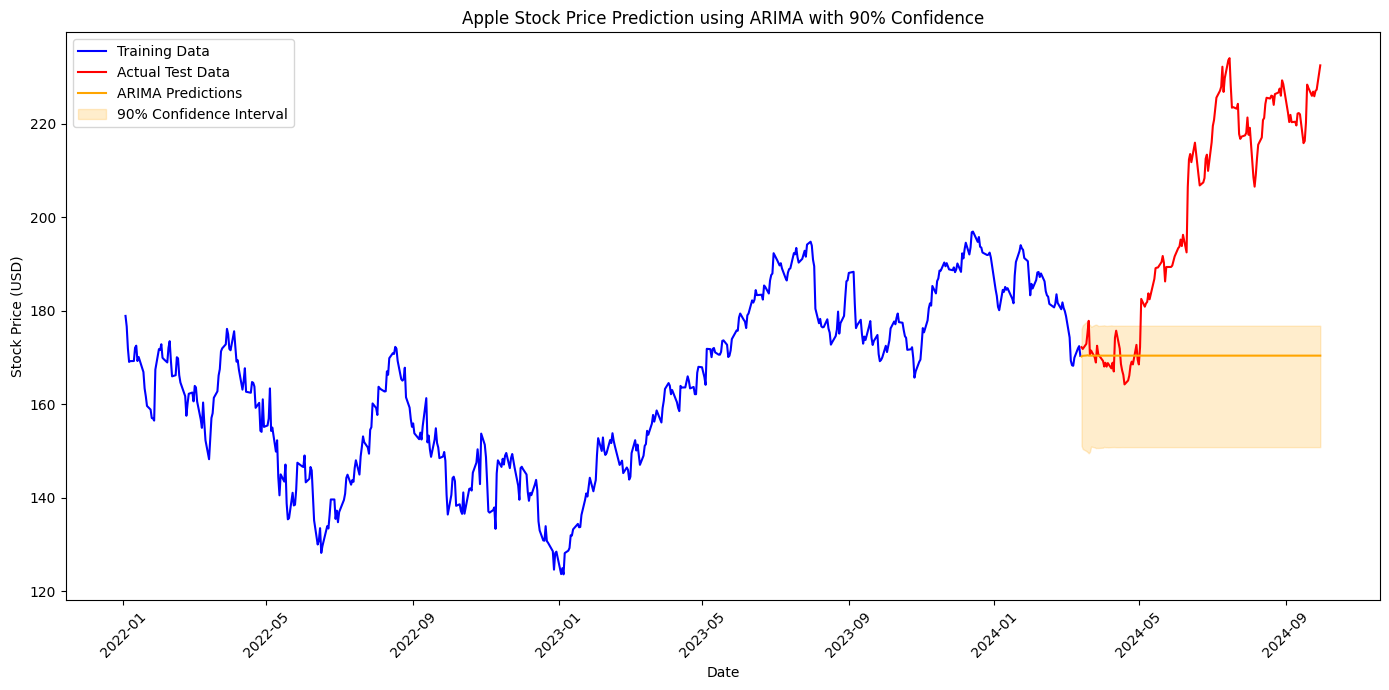

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.utils import resample

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2022-01-01', end='2024-10-01')

# 2. Prepare Data for ARIMA (Use Close Price)
data = df['Close']

# 3. Train-Test Split
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# 4. Fit ARIMA Model (p, d, q parameters need to be tuned)
model = ARIMA(train, order=(5, 1, 0)) # Adjust p, d, q based on your data analysis
model_fit = model.fit()

# 5. Make Predictions
predictions = model_fit.predict(start=len(train), end=len(data) - 1, typ='levels')

# 6. Bootstrap Confidence Intervals
n_bootstraps = 1000
bootstrap_predictions = []
for _ in range(n_bootstraps):
    train_resampled = resample(train, replace=True) # Resample the training data
    model_resampled = ARIMA(train_resampled, order=(5, 1, 0)) # Retrain on resampled data
    model_fit_resampled = model_resampled.fit()
    resampled_predictions = model_fit_resampled.predict(start=len(train), end=len(data) - 1, typ='levels')
    bootstrap_predictions.append(resampled_predictions)

bootstrap_predictions = np.array(bootstrap_predictions)
lower_bounds = np.percentile(bootstrap_predictions, 5, axis=0) # 90% confidence interval (5th percentile)
upper_bounds = np.percentile(bootstrap_predictions, 95, axis=0) # 90% confidence interval (95th percentile)

# 7. Evaluate Performance (RMSE)
rmse = sqrt(mean_squared_error(test, predictions))
print(f'Test RMSE: {rmse}')

# 8. Plot Results with Confidence Intervals
plt.figure(figsize=(14, 7))
plt.plot(data.index[:train_size], train, label='Training Data', color='blue')
plt.plot(data.index[train_size:], test, label='Actual Test Data', color='red')
plt.plot(data.index[train_size:], predictions, label='ARIMA Predictions', color='orange')
plt.fill_between(data.index[train_size:], lower_bounds, upper_bounds, color='orange', alpha=0.2, label='90% Confidence Interval')
plt.title('Apple Stock Price Prediction using ARIMA with 90% Confidence')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, f

Test RMSE: 37.17843543610497


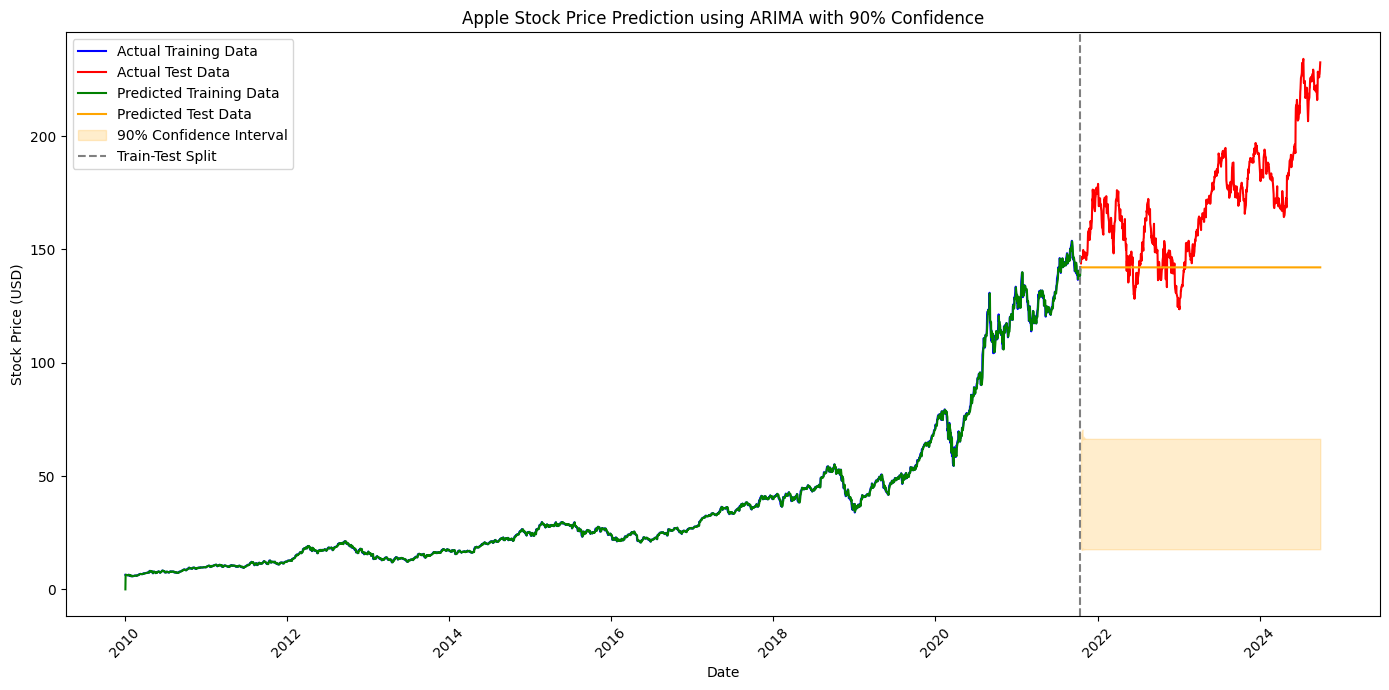

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.utils import resample

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2010-01-01', end='2024-10-01')

# 2. Prepare Data for ARIMA (Use Close Price)
data = df['Close']

# 3. Train-Test Split
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# 4. Fit ARIMA Model (p, d, q parameters need to be tuned)
model = ARIMA(train, order=(5, 1, 0)) # Adjust p, d, q based on your data analysis
model_fit = model.fit()

# 5. Make Predictions for Training and Test
train_predictions = model_fit.predict(start=0, end=train_size - 1, typ='levels')
test_predictions = model_fit.predict(start=train_size, end=len(data) - 1, typ='levels')

# 6. Bootstrap Confidence Intervals (for test predictions)
n_bootstraps = 1000
bootstrap_predictions = []
for _ in range(n_bootstraps):
    train_resampled = resample(train, replace=True)
    model_resampled = ARIMA(train_resampled, order=(5, 1, 0))
    model_fit_resampled = model_resampled.fit()
    resampled_predictions = model_fit_resampled.predict(start=train_size, end=len(data) - 1, typ='levels')
    bootstrap_predictions.append(resampled_predictions)

bootstrap_predictions = np.array(bootstrap_predictions)
lower_bounds = np.percentile(bootstrap_predictions, 5, axis=0)
upper_bounds = np.percentile(bootstrap_predictions, 95, axis=0)

# 7. Evaluate Performance (RMSE)
rmse = sqrt(mean_squared_error(test, test_predictions))
print(f'Test RMSE: {rmse}')

# 8. Plot Results with Confidence Intervals and Train/Test Split
plt.figure(figsize=(14, 7))
plt.plot(data.index[:train_size], train, label='Actual Training Data', color='blue')
plt.plot(data.index[train_size:], test, label='Actual Test Data', color='red')
plt.plot(data.index[:train_size], train_predictions, label='Predicted Training Data', color='green')
plt.plot(data.index[train_size:], test_predictions, label='Predicted Test Data', color='orange')
plt.fill_between(data.index[train_size:], lower_bounds, upper_bounds, color='orange', alpha=0.2, label='90% Confidence Interval')

# Add vertical line for train-test split
split_date = data.index[train_size - 1]
plt.axvline(x=split_date, color='gray', linestyle='--', label='Train-Test Split')

plt.title('Apple Stock Price Prediction using ARIMA with 90% Confidence')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

YF.download() has changed argument auto_adjust default to True


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, f

Test RMSE: 37.17842389973789


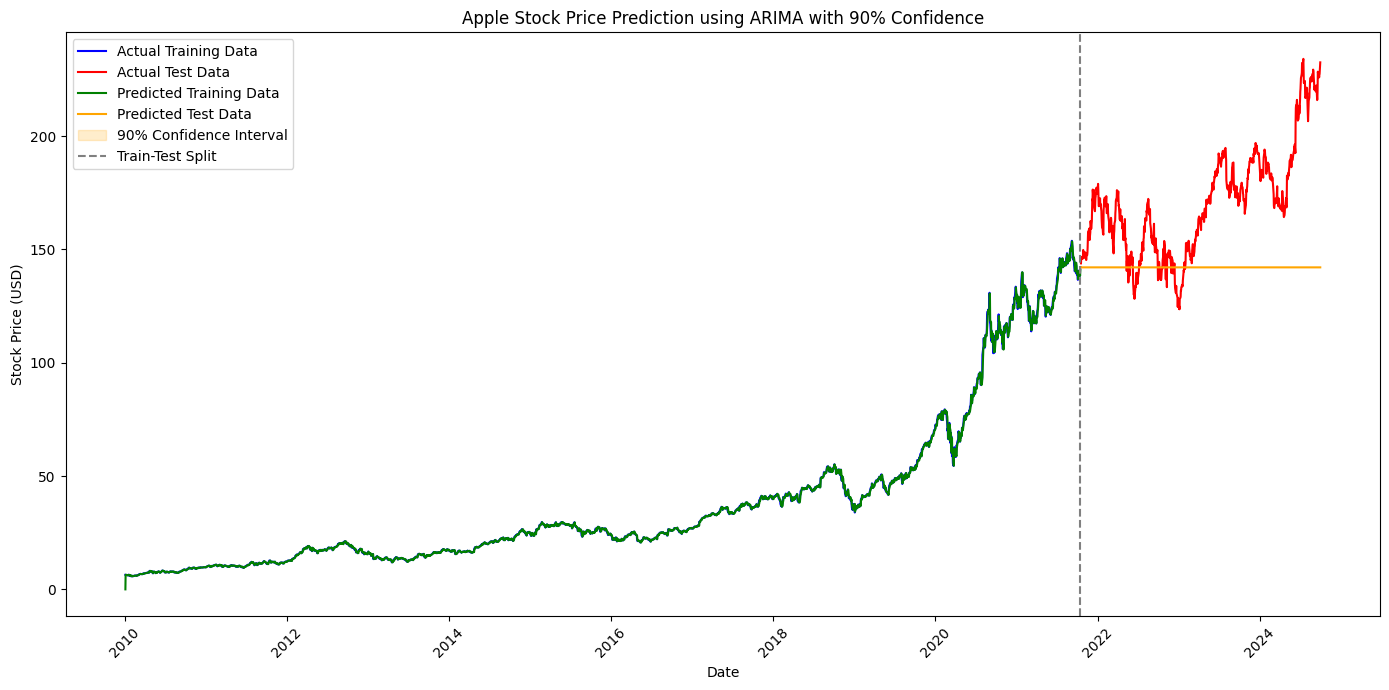

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.utils import resample

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2010-01-01', end='2024-10-01') # Changed start date

# 2. Prepare Data for ARIMA (Use Close Price)
data = df['Close']

# 3. Train-Test Split
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# 4. Fit ARIMA Model (p, d, q parameters need to be tuned)
model = ARIMA(train, order=(5, 1, 0)) # Adjust p, d, q based on your data analysis
model_fit = model.fit()

# 5. Make Predictions for Training and Test
train_predictions = model_fit.predict(start=0, end=train_size - 1, typ='levels')
test_predictions = model_fit.predict(start=train_size, end=len(data) - 1, typ='levels')

# 6. Bootstrap Confidence Intervals (for test predictions)
n_bootstraps = 1000
bootstrap_predictions = []
test_index = data.index[train_size:] # Get the original test index
for _ in range(n_bootstraps):
    train_resampled = resample(train, replace=True)
    model_resampled = ARIMA(train_resampled, order=(5, 1, 0))
    model_fit_resampled = model_resampled.fit()
    resampled_predictions = model_fit_resampled.predict(start=len(train), end=len(data) - 1, typ='levels')
    # Align resampled predictions with original test index
    resampled_predictions_aligned = pd.Series(resampled_predictions, index=test_index)
    bootstrap_predictions.append(resampled_predictions_aligned)

bootstrap_predictions = pd.DataFrame(bootstrap_predictions) # Convert to DataFrame for easier percentile calculation
lower_bounds = bootstrap_predictions.quantile(0.05).values # 5th percentile
upper_bounds = bootstrap_predictions.quantile(0.95).values # 95th percentile

# 7. Evaluate Performance (RMSE)
rmse = sqrt(mean_squared_error(test, test_predictions))
print(f'Test RMSE: {rmse}')

# 8. Plot Results with Confidence Intervals and Train/Test Split
plt.figure(figsize=(14, 7))
plt.plot(data.index[:train_size], train, label='Actual Training Data', color='blue')
plt.plot(data.index[train_size:], test, label='Actual Test Data', color='red')
plt.plot(data.index[:train_size], train_predictions, label='Predicted Training Data', color='green')
plt.plot(data.index[train_size:], test_predictions, label='Predicted Test Data', color='orange')
plt.fill_between(data.index[train_size:], lower_bounds, upper_bounds, color='orange', alpha=0.2, label='90% Confidence Interval')

# Add vertical line for train-test split
split_date = data.index[train_size - 1]
plt.axvline(x=split_date, color='gray', linestyle='--', label='Train-Test Split')

plt.title('Apple Stock Price Prediction using ARIMA with 90% Confidence')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, f

Test RMSE: 18.471408144893392


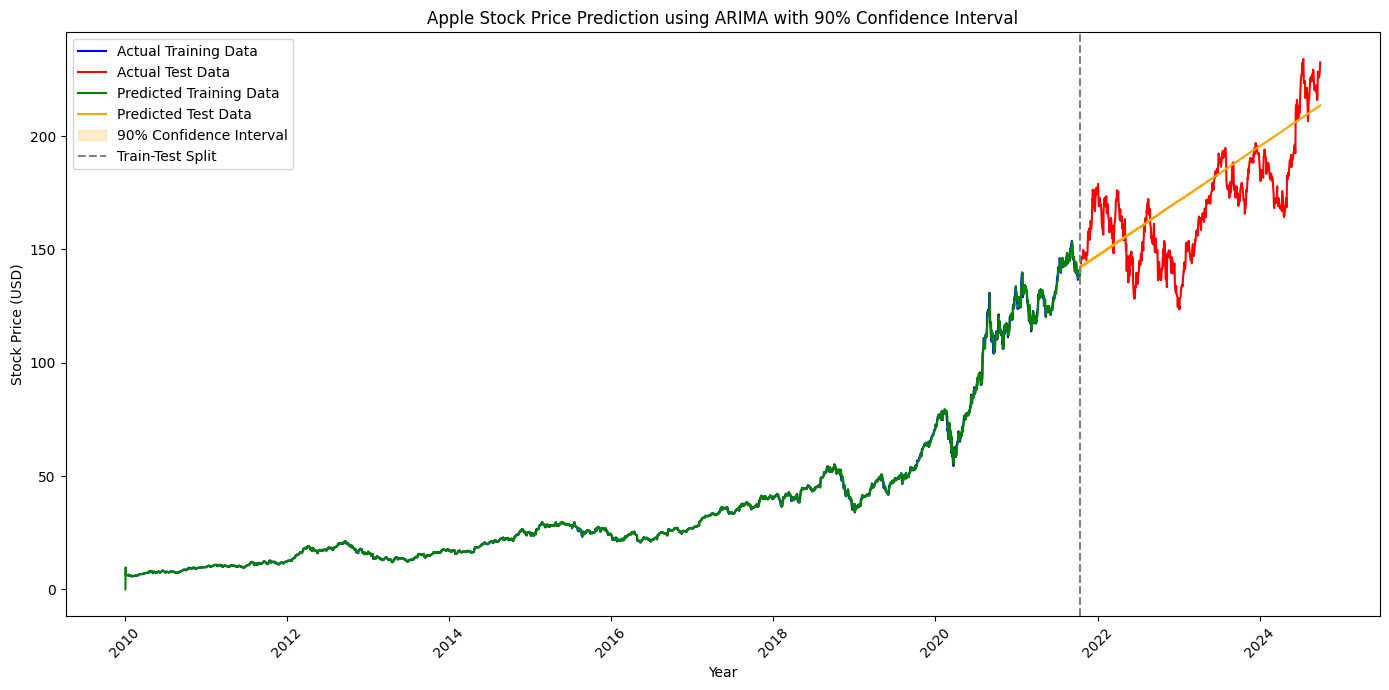

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.utils import resample

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2010-01-01', end='2024-10-01')  # Adjusted dates
df = df[['Close']]  # Focus only on the 'Close' price for prediction

# 2. Prepare Data for ARIMA (Use Close Price)
data = df['Close']

# 3. Train-Test Split (80% for training, 20% for testing)
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# 4. Fit ARIMA Model (p, d, q parameters need to be tuned based on AIC/BIC)
model = ARIMA(train, order=(3, 2, 4))  # Example parameters (5, 1, 0), change as needed
model_fit = model.fit()

# 5. Make Predictions for Training and Test Set
train_predictions = model_fit.predict(start=0, end=train_size - 1, typ='levels')
test_predictions = model_fit.predict(start=train_size, end=len(data) - 1, typ='levels')

# 6. Bootstrap Confidence Intervals (for test predictions)
n_bootstraps = 1000
bootstrap_predictions = []
test_index = data.index[train_size:]  # Get the original test index
for _ in range(n_bootstraps):
    train_resampled = resample(train, replace=True)
    model_resampled = ARIMA(train_resampled, order=(5, 1, 0))
    model_fit_resampled = model_resampled.fit()
    resampled_predictions = model_fit_resampled.predict(start=len(train), end=len(data) - 1, typ='levels')
    resampled_predictions_aligned = pd.Series(resampled_predictions, index=test_index)
    bootstrap_predictions.append(resampled_predictions_aligned)

# Convert to DataFrame for easier percentile calculation
bootstrap_predictions = pd.DataFrame(bootstrap_predictions)

# Calculate the 5th and 95th percentiles for the 90% confidence interval
lower_bounds = bootstrap_predictions.quantile(0.05, axis=0).values  # 5th percentile (lower bound)
upper_bounds = bootstrap_predictions.quantile(0.95, axis=0).values  # 95th percentile (upper bound)

# 7. Evaluate Performance (RMSE)
rmse = sqrt(mean_squared_error(test, test_predictions))
print(f'Test RMSE: {rmse}')

# 8. Plot Results with Confidence Intervals and Train/Test Split
plt.figure(figsize=(14, 7))
plt.plot(data.index[:train_size], train, label='Actual Training Data', color='blue')
plt.plot(data.index[train_size:], test, label='Actual Test Data', color='red')
plt.plot(data.index[:train_size], train_predictions, label='Predicted Training Data', color='green')
plt.plot(data.index[train_size:], test_predictions, label='Predicted Test Data', color='orange')

# Fill between the lower and upper bounds to show the 90% confidence interval
plt.fill_between(data.index[train_size:], lower_bounds, upper_bounds, color='orange', alpha=0.2, label='90% Confidence Interval')

# Add vertical line for train-test split
split_date = data.index[train_size - 1]
plt.axvline(x=split_date, color='gray', linestyle='--', label='Train-Test Split')

plt.title('Apple Stock Price Prediction using ARIMA with 90% Confidence Interval')
plt.xlabel('Year')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index 

     p  d  q        RMSE
0    0  0  0  134.427151
1    0  0  1  134.369648
2    0  0  2  134.343586
3    0  0  3  134.312296
4    0  0  4  134.288979
..  .. .. ..         ...
103  5  2  1   22.745096
104  5  2  2   22.634866
105  5  2  3   21.436766
106  5  2  4   25.161109
107  5  2  5   21.328380

[108 rows x 4 columns]


<Figure size 1200x700 with 0 Axes>

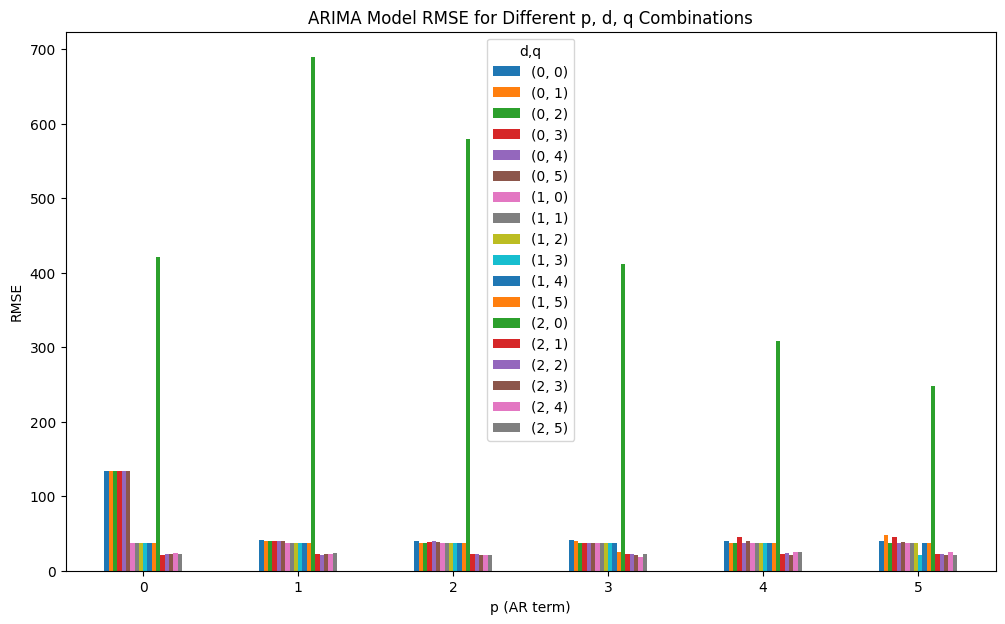

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn.utils import resample

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2010-01-01', end='2024-10-01')

# 2. Prepare Data for ARIMA (Use Close Price)
data = df['Close']

# 3. Train-Test Split
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Function to fit ARIMA model and calculate RMSE for different p, d, q values
def evaluate_arima_model(train, test, p_values, d_values, q_values):
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                # Fit ARIMA Model
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()

                # Make Predictions
                train_predictions = model_fit.predict(start=0, end=train_size - 1, typ='levels')
                test_predictions = model_fit.predict(start=train_size, end=len(data) - 1, typ='levels')

                # Calculate RMSE
                rmse = sqrt(mean_squared_error(test, test_predictions))

                # Store the results
                results.append((p, d, q, rmse))

    return results

# Define p, d, q ranges to test
p_values = range(0, 6)  # AR terms
d_values = range(0, 3)  # Differencing terms
q_values = range(0, 6)  # MA terms

# Get the results
results = evaluate_arima_model(train, test, p_values, d_values, q_values)

# Convert the results to a DataFrame
results_df = pd.DataFrame(results, columns=['p', 'd', 'q', 'RMSE'])

# Display the results table
print(results_df)

# Create a pivot table for visualization
pivot_df = results_df.pivot_table(values='RMSE', index='p', columns=['d', 'q'])

# Plot the results
plt.figure(figsize=(12, 7))
pivot_df.plot(kind='bar', figsize=(12, 7))
plt.title('ARIMA Model RMSE for Different p, d, q Combinations')
plt.xlabel('p (AR term)')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.show()


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index 

All ARIMA(p, d, q) combinations with RMSE:
     p  d  q        RMSE
0    0  0  0  134.427151
1    0  0  1  134.369648
2    0  0  2  134.343586
3    0  0  3  134.312296
4    0  0  4  134.288979
..  .. .. ..         ...
103  5  2  1   22.745096
104  5  2  2   22.634866
105  5  2  3   21.436766
106  5  2  4   25.161109
107  5  2  5   21.328380

[108 rows x 4 columns]

Top 10 ARIMA(p, d, q) Combinations with Lowest RMSE:
     p  d  q       RMSE
70   3  2  4  18.471408
32   1  2  2  20.682578
13   0  2  1  20.742615
51   2  2  3  21.299669
107  5  2  5  21.328380
87   4  2  3  21.351578
69   3  2  3  21.362810
53   2  2  5  21.363099
52   2  2  4  21.371736
105  5  2  3  21.436766


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


<Figure size 1200x700 with 0 Axes>

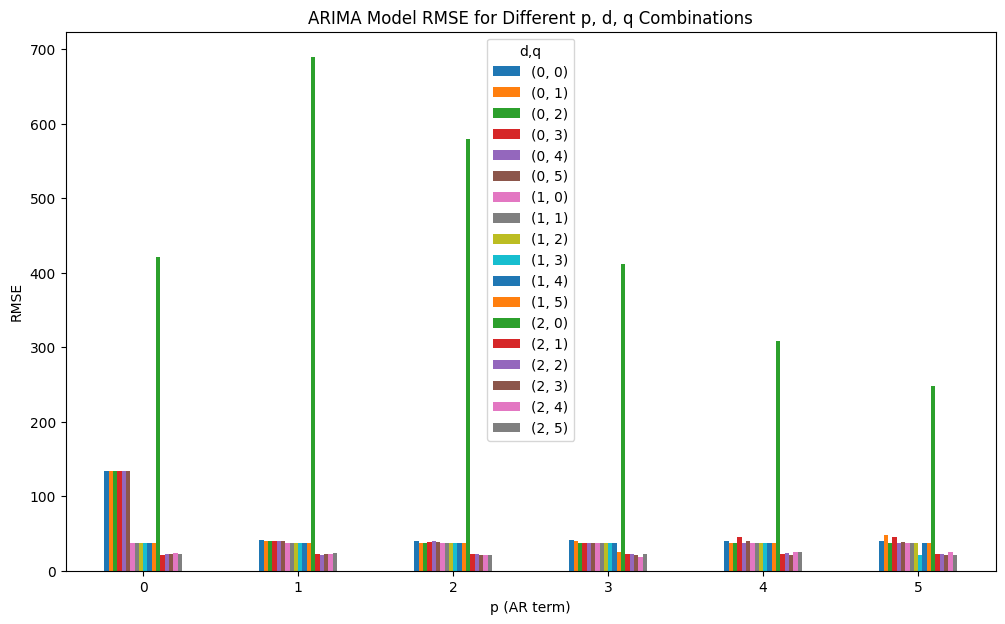

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

# 1. Download Apple Stock Data
df = yf.download('AAPL', start='2010-01-01', end='2024-10-01')

# 2. Prepare Data for ARIMA (Use Close Price)
data = df['Close']

# 3. Train-Test Split
train_size = int(len(data) * 0.8)
train, test = data[:train_size], data[train_size:]

# Function to fit ARIMA model and calculate RMSE for different p, d, q values
def evaluate_arima_model(train, test, p_values, d_values, q_values):
    results = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                # Fit ARIMA Model
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()

                # Make Predictions
                train_predictions = model_fit.predict(start=0, end=train_size - 1, typ='levels')
                test_predictions = model_fit.predict(start=train_size, end=len(data) - 1, typ='levels')

                # Calculate RMSE
                rmse = sqrt(mean_squared_error(test, test_predictions))

                # Store the results
                results.append((p, d, q, rmse))

    return results

# Define p, d, q ranges to test
p_values = range(0, 6)  # AR terms
d_values = range(0, 3)  # Differencing terms
q_values = range(0, 6)  # MA terms

# Get the results
results = evaluate_arima_model(train, test, p_values, d_values, q_values)

# Convert the results to a DataFrame
results_df = pd.DataFrame(results, columns=['p', 'd', 'q', 'RMSE'])

# Display the full results table
print("All ARIMA(p, d, q) combinations with RMSE:")
print(results_df)

# Sort the results by RMSE in ascending order and select the top 10
best_results = results_df.sort_values(by='RMSE').head(10)

# Display the best 10 combinations
print("\nTop 10 ARIMA(p, d, q) Combinations with Lowest RMSE:")
print(best_results)

# Create a pivot table for visualization
pivot_df = results_df.pivot_table(values='RMSE', index='p', columns=['d', 'q'])

# Plot the results
plt.figure(figsize=(12, 7))
pivot_df.plot(kind='bar', figsize=(12, 7))
plt.title('ARIMA Model RMSE for Different p, d, q Combinations')
plt.xlabel('p (AR term)')
plt.ylabel('RMSE')
plt.xticks(rotation=0)
plt.show()


[*********************100%***********************]  1 of 1 completed


Test Set - Mean Squared Error (MSE): 1019.9537681219018
Test Set - Mean Absolute Error (MAE): 24.072802678776174
Train Set - Mean Squared Error (MSE): 0.7727135973459545
Train Set - Mean Absolute Error (MAE): 0.5267025969779214


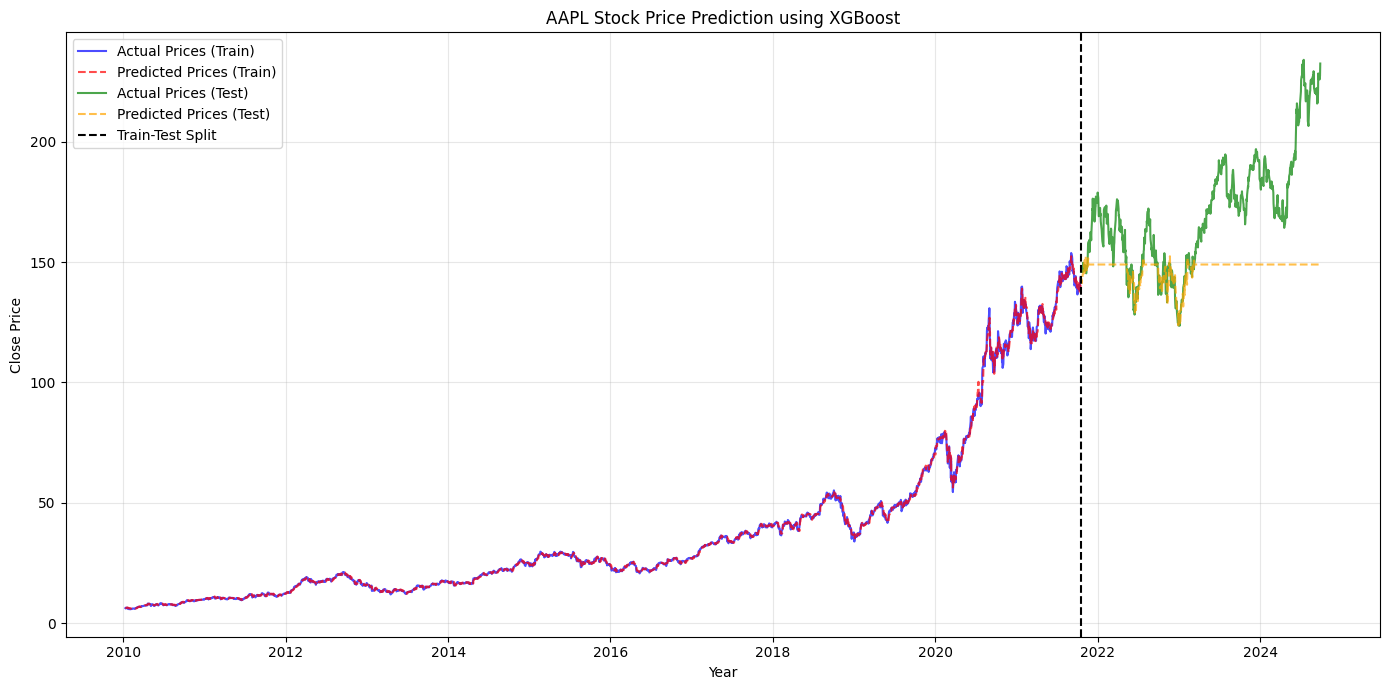

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt

# Step 1: Fetch historical stock data for Apple (AAPL)
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
data = data[['Close']]  # Use only the 'Close' price for prediction

# Step 2: Preprocess the data
# Create a target variable (shift the 'Close' price to predict the next day's price)
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaN values (last row will have NaN for 'Target')
data.dropna(inplace=True)

# Create features (e.g., using past 5 days' closing prices)
lookback = 5
for i in range(1, lookback + 1):
    data[f'Close_{i}'] = data['Close'].shift(i)

# Drop rows with NaN values (first few rows will have NaN for the shifted features)
data.dropna(inplace=True)

# Define features (X) and target (y)
X = data.drop(columns=['Close', 'Target'])
y = data['Target']

# Step 3: Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Preserve the dates for plotting
train_dates = data.index[:len(X_train)]
test_dates = data.index[-len(X_test):]

# Step 4: Train an XGBoost model
# Create an XGBoost regression model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',  # Regression task
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Learning rate
    max_depth=5,                  # Maximum depth of a tree
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

# Step 5: Make predictions
# Predict on the training set
y_train_pred = xgb_model.predict(X_train)

# Predict on the test set
y_test_pred = xgb_model.predict(X_test)

# Step 6: Evaluate the model's performance
# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f"Test Set - Mean Squared Error (MSE): {mse_test}")
print(f"Test Set - Mean Absolute Error (MAE): {mae_test}")

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
print(f"Train Set - Mean Squared Error (MSE): {mse_train}")
print(f"Train Set - Mean Absolute Error (MAE): {mae_train}")

# Step 7: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
plt.plot(train_dates, y_train, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(train_dates, y_train_pred, label='Predicted Prices (Train)', color='red', linestyle='--', alpha=0.7)

# Plot test set results
plt.plot(test_dates, y_test, label='Actual Prices (Test)', color='green', alpha=0.7)
plt.plot(test_dates, y_test_pred, label='Predicted Prices (Test)', color='orange', linestyle='--', alpha=0.7)

# Add vertical line to separate train and test sets
plt.axvline(x=test_dates[0], color='black', linestyle='--', label='Train-Test Split')

# Add labels, title, and legend
plt.title(f"{ticker} Stock Price Prediction using XGBoost")
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Top 10 Hyperparameter Combinations:
                                               params  mean_test_score
3   {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alp...      -626.032751
37  {'subsample': 0.9, 'reg_lambda': 0, 'reg_alpha...      -628.283185
40  {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alp...      -628.467069
6   {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp...      -628.703856
11  {'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp...      -629.590653
5   {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alp...      -630.283412
43  {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha...      -631.324053
21  {'subsample': 0.8, 'reg_lambda': 0.5, 'reg_alp...      -631.358147
41  {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alp...      -631.556011
18  {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha...      -631.642453
Test Set - Mean Squared Error (MSE): 1013.0874746256501
Test Set - Mean Absolute Error (MAE): 23.942797147310696
Train Set - Mean Squared Error (MSE): 1.3683319709972783
Train Set - M

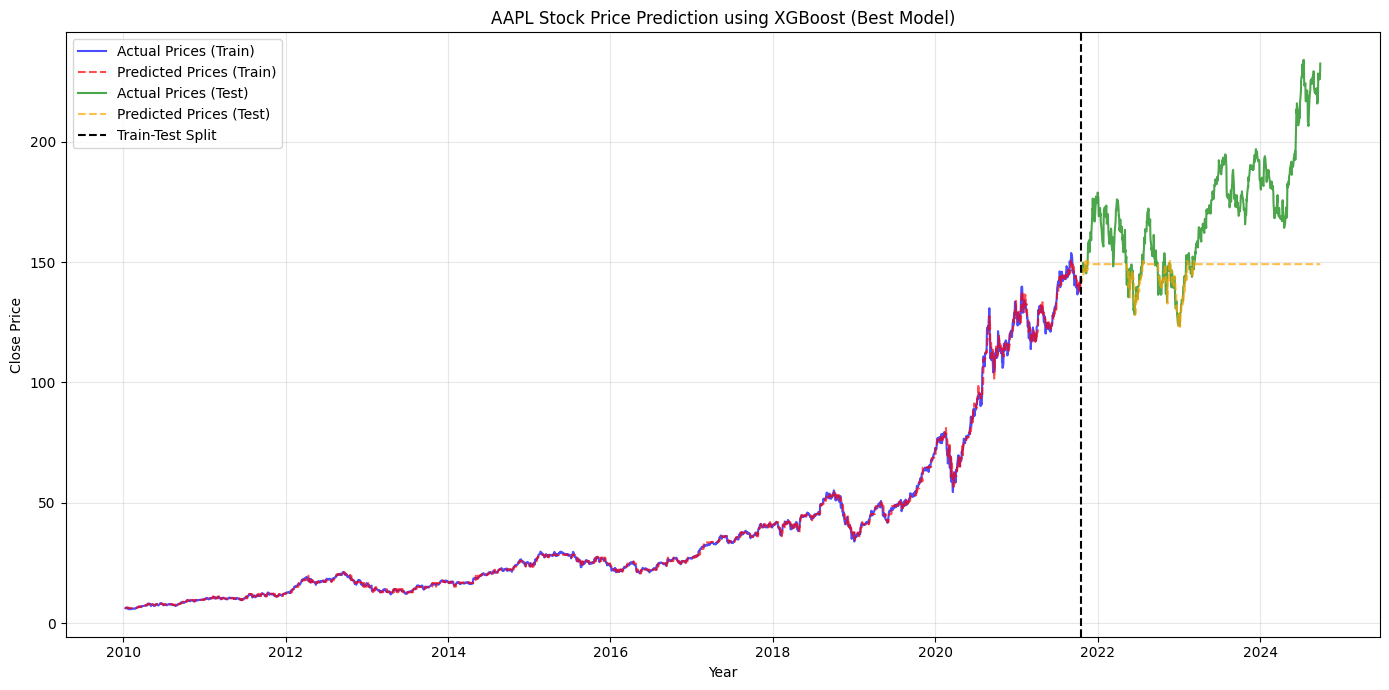

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt

# Step 1: Fetch historical stock data for Apple (AAPL)
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
data = data[['Close']]  # Use only the 'Close' price for prediction

# Step 2: Preprocess the data
# Create a target variable (shift the 'Close' price to predict the next day's price)
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaN values (last row will have NaN for 'Target')
data.dropna(inplace=True)

# Create features (e.g., using past 5 days' closing prices)
lookback = 5
for i in range(1, lookback + 1):
    data[f'Close_{i}'] = data['Close'].shift(i)

# Drop rows with NaN values (first few rows will have NaN for the shifted features)
data.dropna(inplace=True)

# Define features (X) and target (y)
X = data.drop(columns=['Close', 'Target'])
y = data['Target']

# Step 3: Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Step 4: Hyperparameter tuning using RandomizedSearchCV
# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [50, 100, 200, 300],  # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  # Learning rate
    'max_depth': [3, 5, 7, 9],  # Maximum depth of a tree
    'subsample': [0.8, 0.9, 1.0],  # Subsample ratio of the training instances
    'colsample_bytree': [0.8, 0.9, 1.0],  # Subsample ratio of columns when constructing each tree
    'gamma': [0, 0.1, 0.2],  # Minimum loss reduction required to make a split
    'reg_alpha': [0, 0.1, 0.5],  # L1 regularization term on weights
    'reg_lambda': [0, 0.1, 0.5]  # L2 regularization term on weights
}

# Create an XGBoost regressor
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Perform RandomizedSearchCV to find the best hyperparameters
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,  # Number of parameter combinations to try
    scoring='neg_mean_squared_error',  # Use RMSE as the evaluation metric
    cv=5,  # 5-fold cross-validation
    verbose=1,
    random_state=42,
    n_jobs=-1  # Use all available CPU cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Step 5: Get the top 10 best hyperparameter combinations
results = pd.DataFrame(random_search.cv_results_)
top_10_combinations = results.sort_values(by='rank_test_score').head(10)[['params', 'mean_test_score']]

# Display the top 10 combinations
print("Top 10 Hyperparameter Combinations:")
print(top_10_combinations)

# Step 6: Train and evaluate the best model
best_model = random_search.best_estimator_

# Predict on the training set
y_train_pred = best_model.predict(X_train)

# Predict on the test set
y_test_pred = best_model.predict(X_test)

# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f"Test Set - Mean Squared Error (MSE): {mse_test}")
print(f"Test Set - Mean Absolute Error (MAE): {mae_test}")

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
print(f"Train Set - Mean Squared Error (MSE): {mse_train}")
print(f"Train Set - Mean Absolute Error (MAE): {mae_train}")

# Step 7: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
plt.plot(X_train.index, y_train, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(X_train.index, y_train_pred, label='Predicted Prices (Train)', color='red', linestyle='--', alpha=0.7)

# Plot test set results
plt.plot(X_test.index, y_test, label='Actual Prices (Test)', color='green', alpha=0.7)
plt.plot(X_test.index, y_test_pred, label='Predicted Prices (Test)', color='orange', linestyle='--', alpha=0.7)

# Add vertical line to separate train and test sets
plt.axvline(x=X_test.index[0], color='black', linestyle='--', label='Train-Test Split')

# Add labels, title, and legend
plt.title(f"{ticker} Stock Price Prediction using XGBoost (Best Model)")
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Test Set - Mean Squared Error (MSE): 1016.8453632305617
Test Set - Mean Absolute Error (MAE): 24.03700625976892
Train Set - Mean Squared Error (MSE): 0.6650974759429771
Train Set - Mean Absolute Error (MAE): 0.5105766403566451


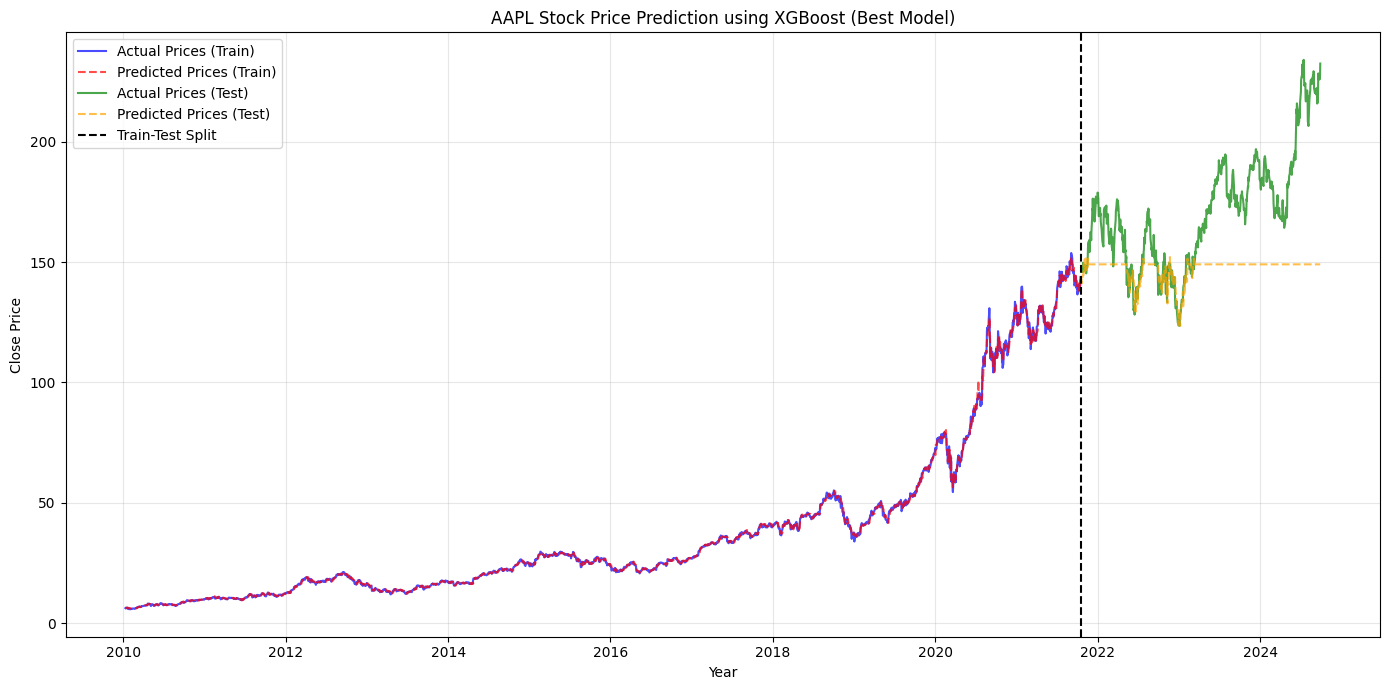

In [ ]:
# Step 1: Define the best hyperparameters
best_params = {
    'subsample': 1.0,
    'reg_lambda': 0.5,
    'reg_alpha': 0.1,
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'gamma': 0.2,
    'colsample_bytree': 0.9
}

# Step 2: Train the final model with the best hyperparameters
final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params  # Unpack the best hyperparameters
)

# Train the model
final_model.fit(X_train, y_train)

# Step 3: Make predictions
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

# Step 4: Evaluate the model
mse_test = mean_squared_error(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print(f"Test Set - Mean Squared Error (MSE): {mse_test}")
print(f"Test Set - Mean Absolute Error (MAE): {mae_test}")

mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
print(f"Train Set - Mean Squared Error (MSE): {mse_train}")
print(f"Train Set - Mean Absolute Error (MAE): {mae_train}")

# Step 5: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
plt.plot(X_train.index, y_train, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(X_train.index, y_train_pred, label='Predicted Prices (Train)', color='red', linestyle='--', alpha=0.7)

# Plot test set results
plt.plot(X_test.index, y_test, label='Actual Prices (Test)', color='green', alpha=0.7)
plt.plot(X_test.index, y_test_pred, label='Predicted Prices (Test)', color='orange', linestyle='--', alpha=0.7)

# Add vertical line to separate train and test sets
plt.axvline(x=X_test.index[0], color='black', linestyle='--', label='Train-Test Split')

# Add labels, title, and legend
plt.title(f"{ticker} Stock Price Prediction using XGBoost (Best Model)")
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


Test Set Metrics:
Mean Squared Error (MSE): 1016.8454
Root Mean Squared Error (RMSE): 31.8880
Mean Absolute Error (MAE): 24.0370
R-squared (R²): -0.7648

Train Set Metrics:
Mean Squared Error (MSE): 0.6651
Root Mean Squared Error (RMSE): 0.8155
Mean Absolute Error (MAE): 0.5106
R-squared (R²): 0.9995


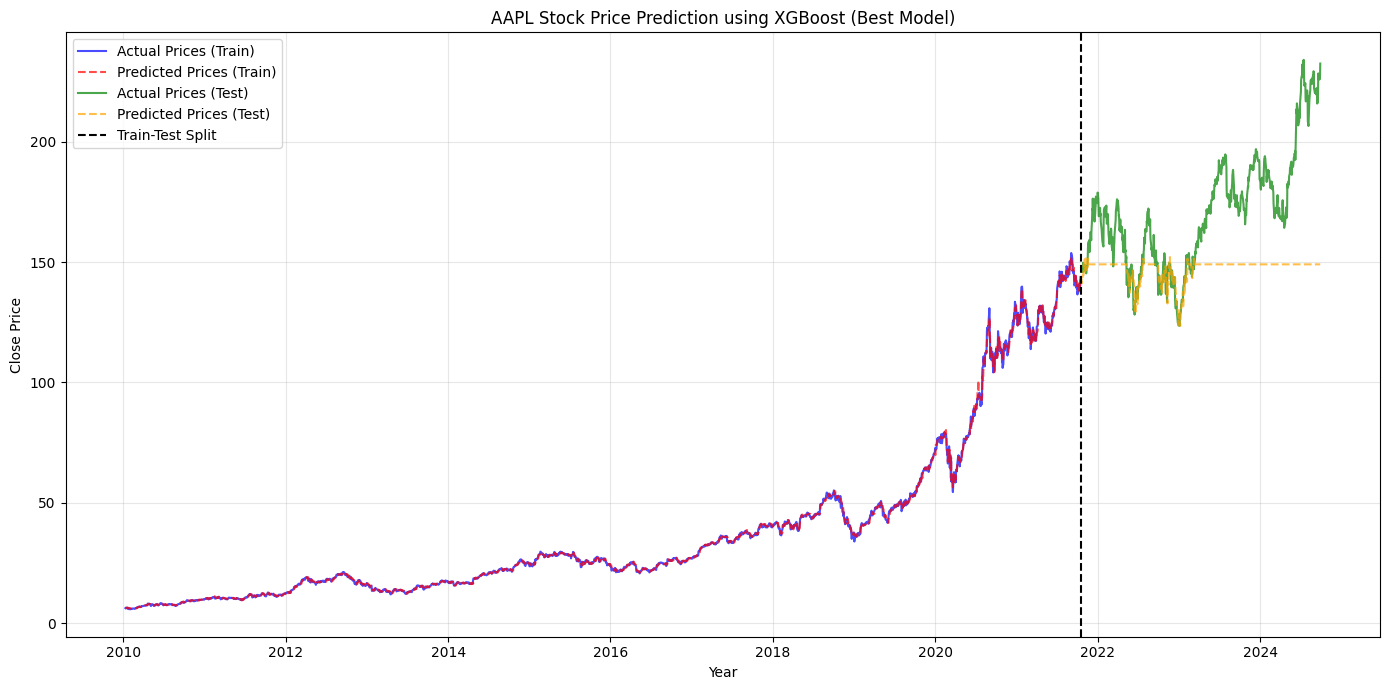

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt

# Step 1: Fetch Apple stock data using yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
data = data[['Close']]  # Use only the 'Close' price for prediction

# Step 2: Preprocess the data
# Create a target variable (shift the 'Close' price to predict the next day's price)
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaN values (last row will have NaN for 'Target')
data.dropna(inplace=True)

# Create features (e.g., using past 5 days' closing prices)
lookback = 5
for i in range(1, lookback + 1):
    data[f'Close_{i}'] = data['Close'].shift(i)

# Drop rows with NaN values (first few rows will have NaN for the shifted features)
data.dropna(inplace=True)

# Define features (X) and target (y)
X = data.drop(columns=['Close', 'Target'])
y = data['Target']

# Step 3: Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Step 4: Define the best hyperparameters
best_params = {
    'subsample': 1.0,
    'reg_lambda': 0.5,
    'reg_alpha': 0.1,
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.1,
    'gamma': 0.2,
    'colsample_bytree': 0.9
}

# Step 5: Train the final model with the best hyperparameters
final_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best_params  # Unpack the best hyperparameters
)

# Train the model
final_model.fit(X_train, y_train)

# Step 6: Make predictions
y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

# Step 7: Evaluate the model
# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Print the results
print("Test Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R-squared (R²): {r2_test:.4f}")

print("\nTrain Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"R-squared (R²): {r2_train:.4f}")

# Step 8: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
plt.plot(X_train.index, y_train, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(X_train.index, y_train_pred, label='Predicted Prices (Train)', color='red', linestyle='--', alpha=0.7)

# Plot test set results
plt.plot(X_test.index, y_test, label='Actual Prices (Test)', color='green', alpha=0.7)
plt.plot(X_test.index, y_test_pred, label='Predicted Prices (Test)', color='orange', linestyle='--', alpha=0.7)

# Add vertical line to separate train and test sets
plt.axvline(x=X_test.index[0], color='black', linestyle='--', label='Train-Test Split')

# Add labels, title, and legend
plt.title(f"{ticker} Stock Price Prediction using XGBoost (Best Model)")
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


Test Set Metrics:
Mean Squared Error (MSE): 5774.7058
Root Mean Squared Error (RMSE): 75.9915
Mean Absolute Error (MAE): 61.4970
R-squared (R²): -9.0224

Train Set Metrics:
Mean Squared Error (MSE): 4.3299
Root Mean Squared Error (RMSE): 2.0808
Mean Absolute Error (MAE): 1.0287
R-squared (R²): 0.9964


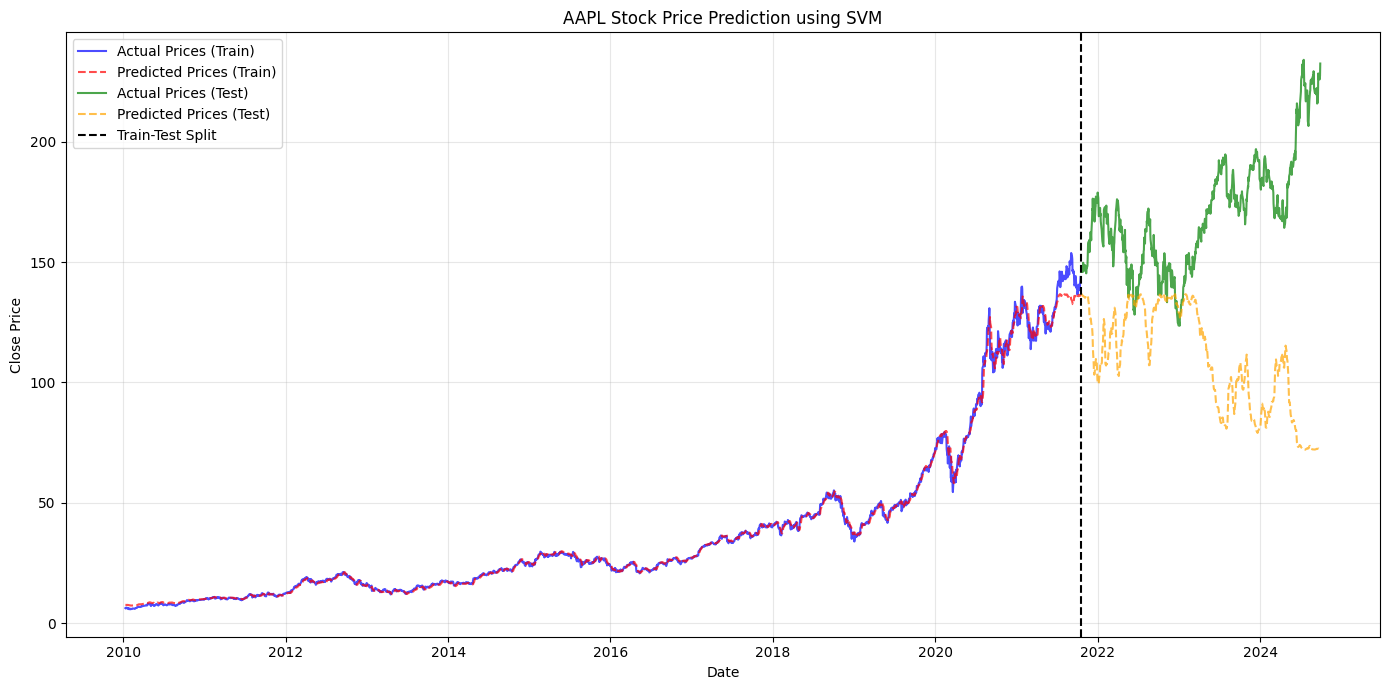

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Fetch historical stock data for Apple (AAPL)
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
data = data[['Close']]  # Use only the 'Close' price for prediction

# Step 2: Preprocess the data
# Create a target variable (shift the 'Close' price to predict the next day's price)
data['Target'] = data['Close'].shift(-1)

# Drop rows with NaN values (last row will have NaN for 'Target')
data.dropna(inplace=True)

# Create features (e.g., using past 5 days' closing prices)
lookback = 5
for i in range(1, lookback + 1):
    data[f'Close_{i}'] = data['Close'].shift(i)

# Drop rows with NaN values (first few rows will have NaN for the shifted features)
data.dropna(inplace=True)

# Define features (X) and target (y)
X = data.drop(columns=['Close', 'Target'])
y = data['Target']

# Step 3: Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Preserve the dates for plotting
train_dates = data.index[:len(X_train)]
test_dates = data.index[-len(X_test):]

# Step 4: Train an SVM model
# Use Support Vector Regression (SVR) for regression tasks
svm_model = SVR(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

# Step 5: Make predictions
# Predict on the training set
y_train_pred = svm_model.predict(X_train)

# Predict on the test set
y_test_pred = svm_model.predict(X_test)

# Step 6: Evaluate the model's performance
# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

# Print the results
print("Test Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R-squared (R²): {r2_test:.4f}")

print("\nTrain Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"R-squared (R²): {r2_train:.4f}")

# Step 7: Plot the results in a single plot
plt.figure(figsize=(14, 7))

# Plot training set results
plt.plot(train_dates, y_train, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(train_dates, y_train_pred, label='Predicted Prices (Train)', color='red', linestyle='--', alpha=0.7)

# Plot test set results
plt.plot(test_dates, y_test, label='Actual Prices (Test)', color='green', alpha=0.7)
plt.plot(test_dates, y_test_pred, label='Predicted Prices (Test)', color='orange', linestyle='--', alpha=0.7)

# Add vertical line to separate train and test sets
plt.axvline(x=test_dates[0], color='black', linestyle='--', label='Train-Test Split')

# Add labels, title, and legend
plt.title(f"{ticker} Stock Price Prediction using SVM")
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0139 - val_loss: 0.0037
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 2.6943e-04 - val_loss: 0.0018
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 1.7627e-04 - val_loss: 9.4235e-04
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 1.1486e-04 - val_loss: 7.5318e-04
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 1.3252e-04 - val_loss: 0.0024
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 1.4323e-04 - val_loss: 0.0010
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 8.2646e-05 - val_loss: 0.0012
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 8.9421e-05 - val_loss: 7.0410e-04
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 8.7182e-05 - val_loss: 8.2860e-04
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - loss: 7.5420e-05 - val_loss: 4.6808e-04
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 6.1867e-05 - val_loss: 5.0606e-04

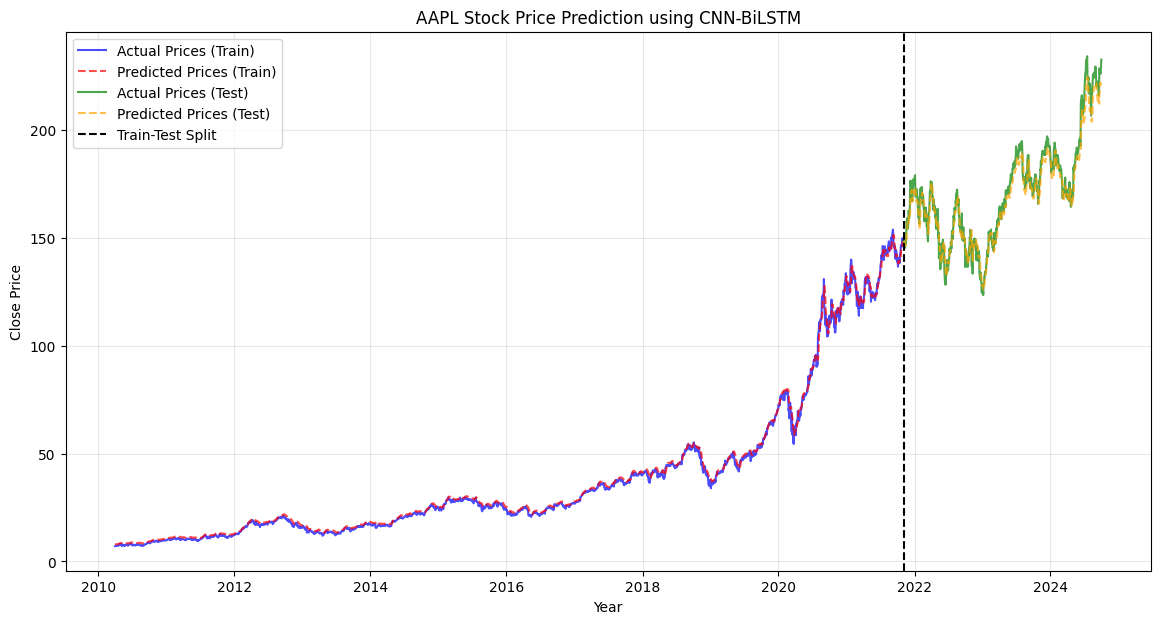

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Fetch Apple stock data using yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
prices = data['Close'].values.reshape(-1, 1)

# Step 2: Preprocess the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Create sequences for time-series prediction
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days of data to predict the next day
X, y = create_sequences(scaled_prices, seq_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be 3D [samples, timesteps, features] for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Step 3: Build the CNN-BiLSTM model
model = Sequential()

# CNN layers
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(seq_length, 1)))
model.add(MaxPooling1D(pool_size=2))

# BiLSTM layer
model.add(Bidirectional(LSTM(50, activation='relu')))

# Fully connected layers
model.add(Dense(25, activation='relu'))
model.add(Dense(1))  # Output layer

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Step 4: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Step 5: Evaluate the model
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_orig = scaler.inverse_transform(y_train)
y_test_orig = scaler.inverse_transform(y_test)

# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test_orig, test_predict)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_orig, test_predict)
r2_test = r2_score(y_test_orig, test_predict)

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train_orig, train_predict)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_orig, train_predict)
r2_train = r2_score(y_train_orig, train_predict)

# Print the results
print("Test Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R-squared (R²): {r2_test:.4f}")

print("\nTrain Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"R-squared (R²): {r2_train:.4f}")

# Step 6: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
train_dates = data.index[seq_length:seq_length + len(y_train)]
plt.plot(train_dates, y_train_orig, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(train_dates, train_predict, label='Predicted Prices (Train)', color='red', linestyle='--', alpha=0.7)

# Plot test set results
test_dates = data.index[seq_length + len(y_train):]
plt.plot(test_dates, y_test_orig, label='Actual Prices (Test)', color='green', alpha=0.7)
plt.plot(test_dates, test_predict, label='Predicted Prices (Test)', color='orange', linestyle='--', alpha=0.7)

# Add vertical line to separate train and test sets
split_date = data.index[train_size + seq_length]
plt.axvline(x=split_date, color='black', linestyle='--', label='Train-Test Split')

# Add labels, title, and legend
plt.title(f"{ticker} Stock Price Prediction using CNN-BiLSTM")
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[*********************100%***********************]  1 of 1 completed

Epoch 1/20


92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 0.0142 - val_loss: 0.0060
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 3.0138e-04 - val_loss: 0.0030
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 2.4115e-04 - val_loss: 0.0063
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.7500e-04 - val_loss: 0.0033
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.8147e-04 - val_loss: 0.0043
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 1.4363e-04 - val_loss: 0.0028
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 1.3463e-04 - val_loss: 0.0020
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.6233e-04 - val_loss: 0.0027
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - loss: 1.1174e-04 - val_loss: 0.0053
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 1.8346e-04 - val_loss: 0.0024
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 1.2426e-04 - val_loss: 0.0026
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━

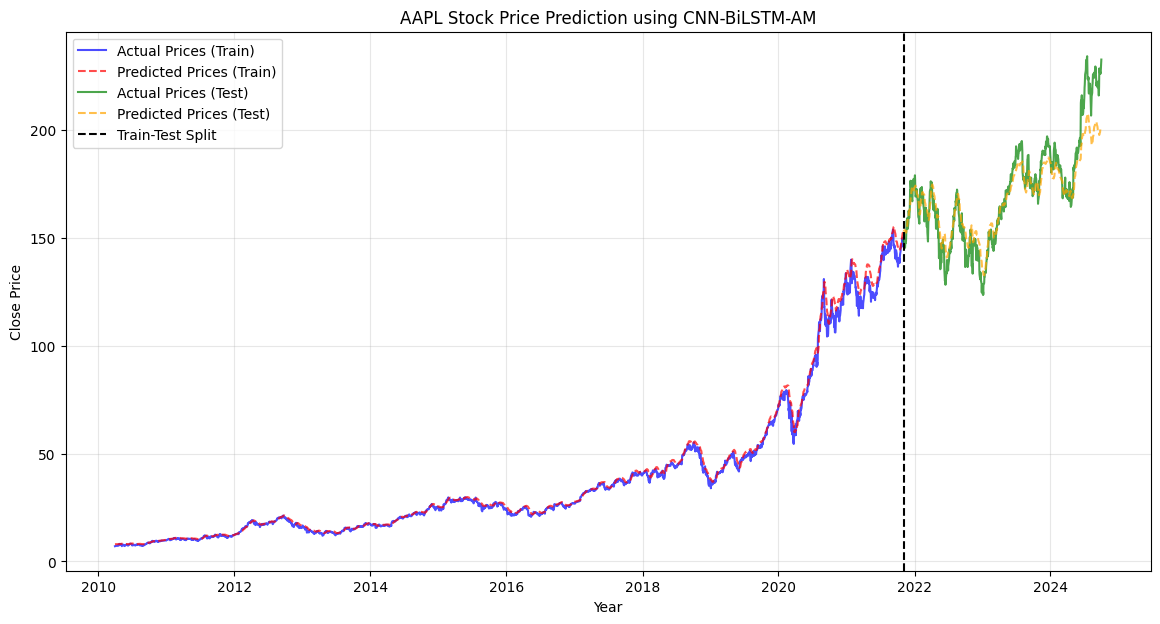

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten, Input, Multiply, Activation, Permute, Reshape
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Step 1: Fetch Apple stock data using yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
prices = data['Close'].values.reshape(-1, 1)

# Step 2: Preprocess the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Create sequences for time-series prediction
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days of data to predict the next day
X, y = create_sequences(scaled_prices, seq_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be 3D [samples, timesteps, features] for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Step 3: Define the Attention Mechanism
def attention_block(inputs):
    # Apply a dense layer to compute attention scores
    attention = Dense(1, activation='tanh')(inputs)
    attention = Flatten()(attention)
    attention = Activation('softmax')(attention)
    attention = Reshape((-1, 1))(attention)

    # Multiply the attention scores with the input
    attention_output = Multiply()([inputs, attention])
    return attention_output

# Step 4: Build the CNN-BiLSTM-AM model
inputs = Input(shape=(seq_length, 1))

# CNN layers
cnn_output = Conv1D(filters=64, kernel_size=3, activation='relu')(inputs)
cnn_output = MaxPooling1D(pool_size=2)(cnn_output)

# BiLSTM layer
bilstm_output = Bidirectional(LSTM(50, return_sequences=True))(cnn_output)

# Attention Mechanism
attention_output = attention_block(bilstm_output)

# Flatten and fully connected layers
flatten_output = Flatten()(attention_output)
dense_output = Dense(25, activation='relu')(flatten_output)
output = Dense(1)(dense_output)

# Create the model
model = Model(inputs, output)

# Compile the model
model.compile(optimizer='adam', loss='mse')

# Step 5: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Step 6: Evaluate the model
# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_orig = scaler.inverse_transform(y_train)
y_test_orig = scaler.inverse_transform(y_test)

# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test_orig, test_predict)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_orig, test_predict)
r2_test = r2_score(y_test_orig, test_predict)

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train_orig, train_predict)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_orig, train_predict)
r2_train = r2_score(y_train_orig, train_predict)

# Print the results
print("Test Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R-squared (R²): {r2_test:.4f}")

print("\nTrain Set Metrics:")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"R-squared (R²): {r2_train:.4f}")

# Step 7: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
train_dates = data.index[seq_length:seq_length + len(y_train)]
plt.plot(train_dates, y_train_orig, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(train_dates, train_predict, label='Predicted Prices (Train)', color='red', linestyle='--', alpha=0.7)

# Plot test set results
test_dates = data.index[seq_length + len(y_train):]
plt.plot(test_dates, y_test_orig, label='Actual Prices (Test)', color='green', alpha=0.7)
plt.plot(test_dates, test_predict, label='Predicted Prices (Test)', color='orange', linestyle='--', alpha=0.7)

# Add vertical line to separate train and test sets
split_date = data.index[train_size + seq_length]
plt.axvline(x=split_date, color='black', linestyle='--', label='Train-Test Split')

# Add labels, title, and legend
plt.title(f"{ticker} Stock Price Prediction using CNN-BiLSTM-AM")
plt.xlabel('Year')
plt.ylabel('Close Price')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[*********************100%***********************]  1 of 1 completed


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step

Top 5 Configurations:
Configuration 6:
Filters: 128, LSTM Units: 100, Learning Rate: 0.001
MSE: 26.7639, RMSE: 5.1734, MAE: 4.0222, R²: 0.9536

Configuration 2:
Filters: 64, LSTM Units: 100, Learning Rate: 0.001
MSE: 32.1172, RMSE: 5.6672, MAE: 4.4910, R²: 0.9443

Configuration 12:
Filters: 32, LSTM Units: 100, Learning Rate: 0.0005
MSE: 37.2294, RMSE: 6.1016, MAE: 4.8472, R²: 0.9354

Configuration 10:
Filters: 32, LSTM Units: 100, Learning Rate: 0.001
MSE: 48.5308, RMSE: 6.9664, MAE: 5.5349, R²: 0.9158

Configura

([<matplotlib.lines.Line2D at 0x7d54da376790>],)

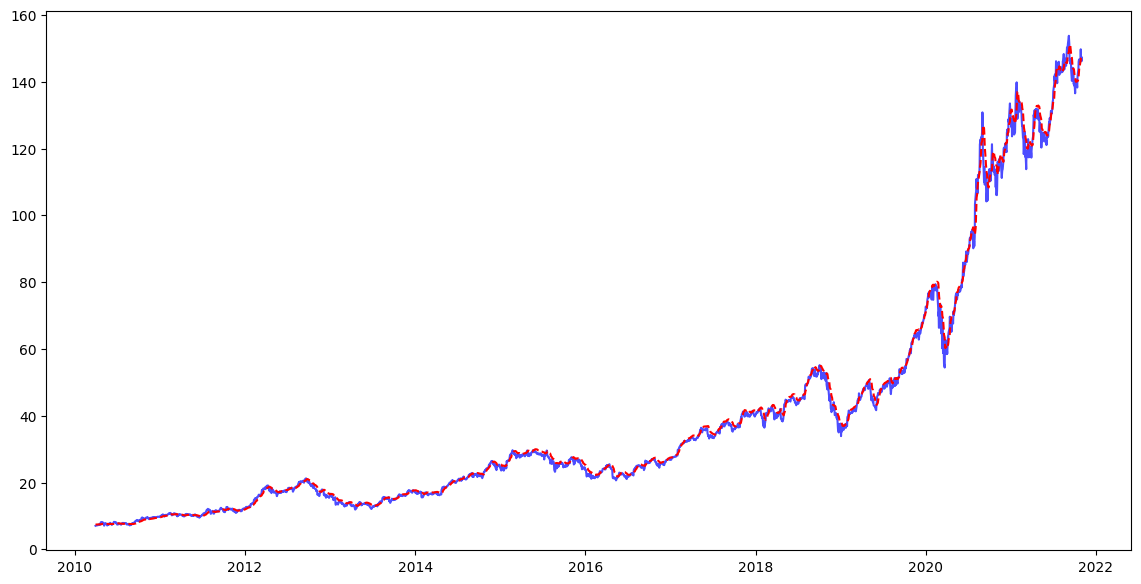

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten, Input, Multiply, Activation, Permute, Reshape
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid

# Step 1: Fetch Apple stock data using yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
prices = data['Close'].values.reshape(-1, 1)

# Step 2: Preprocess the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Create sequences for time-series prediction
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days of data to predict the next day
X, y = create_sequences(scaled_prices, seq_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be 3D [samples, timesteps, features] for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Step 3: Define the Attention Mechanism
def attention_block(inputs):
    attention = Dense(1, activation='tanh')(inputs)
    attention = Flatten()(attention)
    attention = Activation('softmax')(attention)
    attention = Reshape((-1, 1))(attention)
    attention_output = Multiply()([inputs, attention])
    return attention_output

# Step 4: Build the CNN-BiLSTM-AM model
def build_model(filters=64, kernel_size=3, lstm_units=50, dense_units=25, learning_rate=0.001):
    inputs = Input(shape=(seq_length, 1))
    cnn_output = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu')(inputs)
    cnn_output = MaxPooling1D(pool_size=2)(cnn_output)
    bilstm_output = Bidirectional(LSTM(lstm_units, return_sequences=True))(cnn_output)
    attention_output = attention_block(bilstm_output)
    flatten_output = Flatten()(attention_output)
    dense_output = Dense(dense_units, activation='relu')(flatten_output)
    output = Dense(1)(dense_output)
    model = Model(inputs, output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Step 5: Hyperparameter Tuning (Top 5 Configurations)
param_grid = {
    'filters': [64, 128, 32],
    'kernel_size': [3],
    'lstm_units': [50, 100],
    'dense_units': [25],
    'learning_rate': [0.001, 0.0005],
    'epochs': [20],
    'batch_size': [32]
}

grid = ParameterGrid(param_grid)
results = []

for params in grid:
    model = build_model(params['filters'], params['kernel_size'], params['lstm_units'], params['dense_units'], params['learning_rate'])
    model.fit(X_train, y_train, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    test_predict = model.predict(X_test)
    test_predict = scaler.inverse_transform(test_predict)
    y_test_orig = scaler.inverse_transform(y_test)
    mse = mean_squared_error(y_test_orig, test_predict)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, test_predict)
    r2 = r2_score(y_test_orig, test_predict)
    results.append({'params': params, 'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2})

results_df = pd.DataFrame(results).sort_values(by='mse')
top_5_results = results_df.head(5)

print("\nTop 5 Configurations:")
for index, row in top_5_results.iterrows():
    print(f"Configuration {index + 1}:")
    print(f"Filters: {row['params']['filters']}, LSTM Units: {row['params']['lstm_units']}, Learning Rate: {row['params']['learning_rate']}")
    print(f"MSE: {row['mse']:.4f}, RMSE: {row['rmse']:.4f}, MAE: {row['mae']:.4f}, R²: {row['r2']:.4f}\n")

# Step 6: Evaluate the best model (using first best config)
best_params = top_5_results.iloc[0]['params']
model = build_model(best_params['filters'], best_params['kernel_size'], best_params['lstm_units'], best_params['dense_units'], best_params['learning_rate'])
model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_data=(X_test, y_test), verbose=1)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_orig = scaler.inverse_transform(y_train)
y_test_orig = scaler.inverse_transform(y_test)

# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test_orig, test_predict)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_orig, test_predict)
r2_test = r2_score(y_test_orig, test_predict)

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train_orig, train_predict)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_orig, train_predict)
r2_train = r2_score(y_train_orig, train_predict)

# Print the results
print("\nTest Set Metrics (Best Model):")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R-squared (R²): {r2_test:.4f}")

print("\nTrain Set Metrics (Best Model):")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"R-squared (R²): {r2_train:.4f}")

# Step 7: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
train_dates = data.index[seq_length:seq_length + len(y_train)]
plt.plot(train_dates, y_train_orig, label='Actual Prices (Train)', color='blue', alpha=0.7)
plt.plot(train_dates, train_predict, label='Predicted Prices (Train)', color='red', linestyle='--'),

[*********************100%***********************]  1 of 1 completed


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Top 5 Configurations:
Configuration 10:
Filters: 32, LSTM Units: 100, Learning Rate: 0.001
MSE: 32.6325, RMSE: 5.7125, MAE: 4.4946, R²: 0.9434

Configuration 1:
Filters: 64, LSTM Units: 50, Learning Rate: 0.001
MSE: 40.7580, RMSE: 6.3842, MAE: 4.9575, R²: 0.9293

Configuration 9:
Filters: 32, LSTM Units: 50, Learning Rate: 0.001
MSE: 42.5094, RMSE: 6.5199, MAE: 5.1237, R²: 0.9262

Configuration 4:
Filters: 64, LSTM Units: 100, Learning Rate: 0.0005
MSE: 44.0948, RMSE: 6.6404, MAE: 5.1885, R²: 0.9235

Configuration

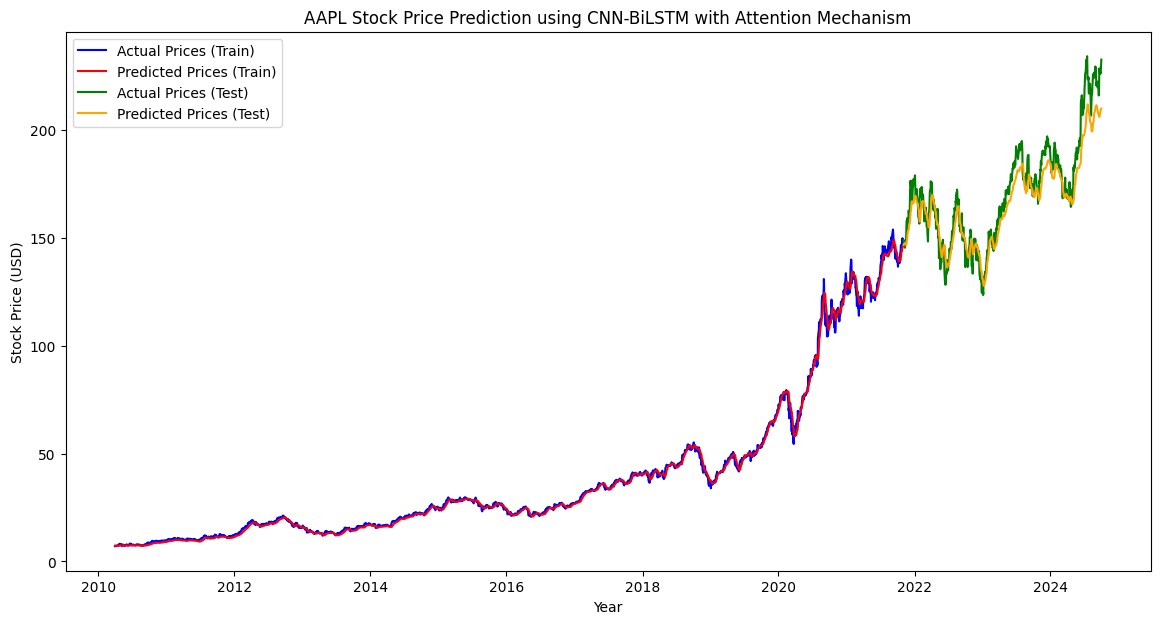

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Flatten, Input, Multiply, Activation, Permute, Reshape
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import ParameterGrid

# Step 1: Fetch Apple stock data using yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
prices = data['Close'].values.reshape(-1, 1)

# Step 2: Preprocess the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Create sequences for time-series prediction
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days of data to predict the next day
X, y = create_sequences(scaled_prices, seq_length)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape input to be 3D [samples, timesteps, features] for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Step 3: Define the Attention Mechanism
def attention_block(inputs):
    attention = Dense(1, activation='tanh')(inputs)
    attention = Flatten()(attention)
    attention = Activation('softmax')(attention)
    attention = Reshape((-1, 1))(attention)
    attention_output = Multiply()([inputs, attention])
    return attention_output

# Step 4: Build the CNN-BiLSTM-AM model
def build_model(filters=64, kernel_size=3, lstm_units=50, dense_units=25, learning_rate=0.001):
    inputs = Input(shape=(seq_length, 1))
    cnn_output = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu')(inputs)
    cnn_output = MaxPooling1D(pool_size=2)(cnn_output)
    bilstm_output = Bidirectional(LSTM(lstm_units, return_sequences=True))(cnn_output)
    attention_output = attention_block(bilstm_output)
    flatten_output = Flatten()(attention_output)
    dense_output = Dense(dense_units, activation='relu')(flatten_output)
    output = Dense(1)(dense_output)
    model = Model(inputs, output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# Step 5: Hyperparameter Tuning (Top 5 Configurations)
param_grid = {
    'filters': [64, 128, 32],
    'kernel_size': [3],
    'lstm_units': [50, 100],
    'dense_units': [25],
    'learning_rate': [0.001, 0.0005],
    'epochs': [20],
    'batch_size': [32]
}

grid = ParameterGrid(param_grid)
results = []

for params in grid:
    model = build_model(params['filters'], params['kernel_size'], params['lstm_units'], params['dense_units'], params['learning_rate'])
    model.fit(X_train, y_train, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    test_predict = model.predict(X_test)
    test_predict = scaler.inverse_transform(test_predict)
    y_test_orig = scaler.inverse_transform(y_test)
    mse = mean_squared_error(y_test_orig, test_predict)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, test_predict)
    r2 = r2_score(y_test_orig, test_predict)
    results.append({'params': params, 'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2})

results_df = pd.DataFrame(results).sort_values(by='mse')
top_5_results = results_df.head(5)

print("\nTop 5 Configurations:")
for index, row in top_5_results.iterrows():
    print(f"Configuration {index + 1}:")
    print(f"Filters: {row['params']['filters']}, LSTM Units: {row['params']['lstm_units']}, Learning Rate: {row['params']['learning_rate']}")
    print(f"MSE: {row['mse']:.4f}, RMSE: {row['rmse']:.4f}, MAE: {row['mae']:.4f}, R²: {row['r2']:.4f}\n")

# Step 6: Evaluate the best model (using first best config)
best_params = top_5_results.iloc[0]['params']
model = build_model(best_params['filters'], best_params['kernel_size'], best_params['lstm_units'], best_params['dense_units'], best_params['learning_rate'])
model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_data=(X_test, y_test), verbose=1)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_orig = scaler.inverse_transform(y_train)
y_test_orig = scaler.inverse_transform(y_test)

# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test_orig, test_predict)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_orig, test_predict)
r2_test = r2_score(y_test_orig, test_predict)

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train_orig, train_predict)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_orig, train_predict)
r2_train = r2_score(y_train_orig, train_predict)

# Print the results
print("\nTest Set Metrics (Best Model):")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R-squared (R²): {r2_test:.4f}")

print("\nTrain Set Metrics (Best Model):")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"R-squared (R²): {r2_train:.4f}")

# Step 7: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
train_dates = data.index[seq_length:seq_length + len(y_train)]
plt.plot(train_dates, y_train_orig, label='Actual Prices (Train)', color='blue')
plt.plot(train_dates, train_predict, label='Predicted Prices (Train)', color='red')

# Plot testing set results
test_dates = data.index[len(y_train) + seq_length:]
plt.plot(test_dates, y_test_orig, label='Actual Prices (Test)', color='green')
plt.plot(test_dates, test_predict, label='Predicted Prices (Test)', color='orange')

plt.title('AAPL Stock Price Prediction using CNN-BiLSTM with Attention Mechanism')
plt.xlabel('Year')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()


[*********************100%***********************]  1 of 1 completed


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step

Top 5 Configurations:
Configuration 8:
Filters: 128, LSTM Units: 100, Learning Rate: 0.0005
MSE: 31.8289, RMSE: 5.6417, MAE: 4.4104, R²: 0.9448

Configuration 2:
Filters: 64, LSTM Units: 100, Learning Rate: 0.001
MSE: 32.8156, RMSE: 5.7285, MAE: 4.4445, R²: 0.9430

Configuration 10:
Filters: 32, LSTM Units: 100, Learning Rate: 0.001
MSE: 33.3842, RMSE: 5.7779, MAE: 4.5298, R²: 0.9421

Configuration 4:
Filters: 64, LSTM Units: 100, Learning Rate: 0.0005
MSE: 38.1170, RMSE: 6.1739, MAE: 4.8942, R²: 0.9338

Configur

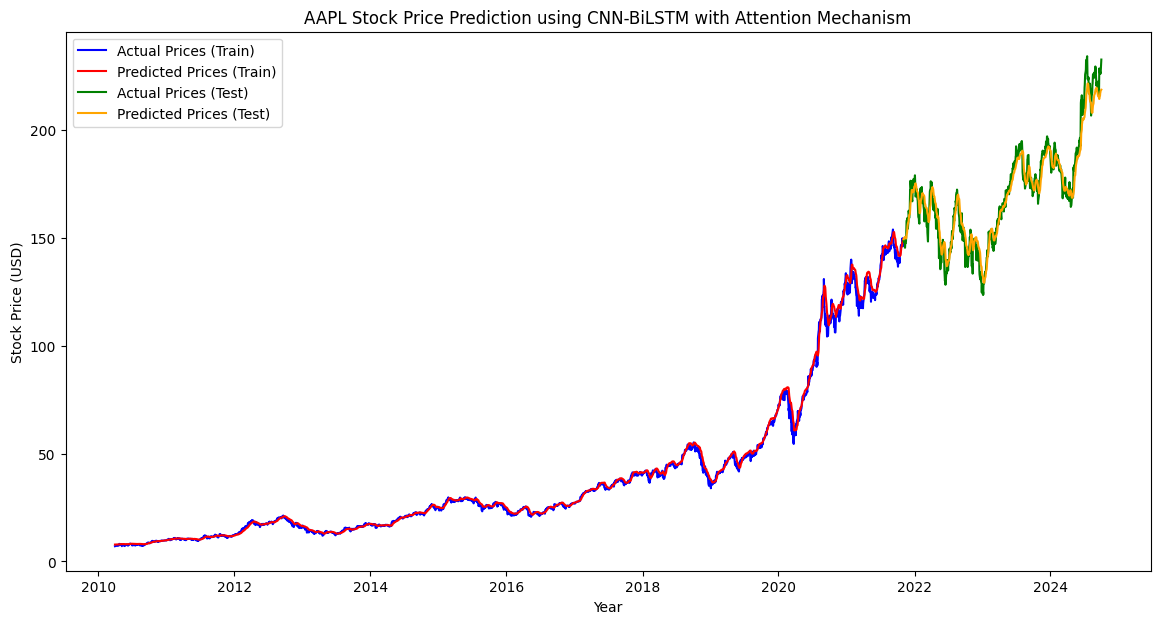

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import ParameterGrid
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Flatten, Activation, Reshape, Multiply

# Step 1: Fetch Apple stock data using yfinance
ticker = "AAPL"
data = yf.download(ticker, start="2010-01-01", end="2024-10-01")
prices = data['Close'].values.reshape(-1, 1)

# Step 2: Preprocess the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_prices = scaler.fit_transform(prices)

# Create sequences for time-series prediction
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 60  # Use 60 days of data to predict the next day
X, y = create_sequences(scaled_prices, seq_length)

# ----------------------------- Train-Test Split -----------------------------
# Step 3: Split data into train and test sets (80% training, 20% testing)
train_size = int(len(X) * 0.8)  # 80% for training, 20% for testing
X_train, X_test = X[:train_size], X[train_size:]  # Split the feature data
y_train, y_test = y[:train_size], y[train_size:]  # Split the target data

# Reshape input to be 3D [samples, timesteps, features] for CNN
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------------- Define Attention Mechanism -----------------------------
# Step 4: Define the Attention Mechanism
def attention_block(inputs):
    attention = Dense(1, activation='tanh')(inputs)
    attention = Flatten()(attention)
    attention = Activation('softmax')(attention)
    attention = Reshape((-1, 1))(attention)
    attention_output = Multiply()([inputs, attention])
    return attention_output

# ----------------------------- Build the Model -----------------------------
# Step 5: Build the CNN-BiLSTM-AM model
def build_model(filters=64, kernel_size=3, lstm_units=50, dense_units=25, learning_rate=0.001):
    inputs = Input(shape=(seq_length, 1))
    cnn_output = Conv1D(filters=filters, kernel_size=kernel_size, activation='relu')(inputs)
    cnn_output = MaxPooling1D(pool_size=2)(cnn_output)
    bilstm_output = Bidirectional(LSTM(lstm_units, return_sequences=True))(cnn_output)
    attention_output = attention_block(bilstm_output)
    flatten_output = Flatten()(attention_output)
    dense_output = Dense(dense_units, activation='relu')(flatten_output)
    output = Dense(1)(dense_output)
    model = Model(inputs, output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return model

# ----------------------------- Hyperparameter Tuning -----------------------------
param_grid = {
    'filters': [64, 128, 32],
    'kernel_size': [3],
    'lstm_units': [50, 100],
    'dense_units': [25],
    'learning_rate': [0.001, 0.0005],
    'epochs': [20],
    'batch_size': [32]
}

grid = ParameterGrid(param_grid)
results = []

for params in grid:
    model = build_model(params['filters'], params['kernel_size'], params['lstm_units'], params['dense_units'], params['learning_rate'])
    model.fit(X_train, y_train, epochs=params['epochs'], batch_size=params['batch_size'], verbose=0)
    test_predict = model.predict(X_test)
    test_predict = scaler.inverse_transform(test_predict)
    y_test_orig = scaler.inverse_transform(y_test)
    mse = mean_squared_error(y_test_orig, test_predict)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, test_predict)
    r2 = r2_score(y_test_orig, test_predict)
    results.append({'params': params, 'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2})

results_df = pd.DataFrame(results).sort_values(by='mse')
top_5_results = results_df.head(5)

print("\nTop 5 Configurations:")
for index, row in top_5_results.iterrows():
    print(f"Configuration {index + 1}:")
    print(f"Filters: {row['params']['filters']}, LSTM Units: {row['params']['lstm_units']}, Learning Rate: {row['params']['learning_rate']}")
    print(f"MSE: {row['mse']:.4f}, RMSE: {row['rmse']:.4f}, MAE: {row['mae']:.4f}, R²: {row['r2']:.4f}\n")

# ----------------------------- Model Evaluation -----------------------------
# Step 6: Evaluate the best model (using first best config)
best_params = top_5_results.iloc[0]['params']
model = build_model(best_params['filters'], best_params['kernel_size'], best_params['lstm_units'], best_params['dense_units'], best_params['learning_rate'])
model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_data=(X_test, y_test), verbose=1)

# Make predictions
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Inverse transform predictions to original scale
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_train_orig = scaler.inverse_transform(y_train)
y_test_orig = scaler.inverse_transform(y_test)

# Calculate evaluation metrics for the test set
mse_test = mean_squared_error(y_test_orig, test_predict)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_orig, test_predict)
r2_test = r2_score(y_test_orig, test_predict)

# Calculate evaluation metrics for the training set
mse_train = mean_squared_error(y_train_orig, train_predict)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_orig, train_predict)
r2_train = r2_score(y_train_orig, train_predict)

# Print the results
print("\nTest Set Metrics (Best Model):")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"R-squared (R²): {r2_test:.4f}")

print("\nTrain Set Metrics (Best Model):")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"R-squared (R²): {r2_train:.4f}")

# ----------------------------- Plot the Results -----------------------------
# Step 7: Plot the results
plt.figure(figsize=(14, 7))

# Plot training set results
train_dates = data.index[seq_length:seq_length + len(y_train)]
plt.plot(train_dates, y_train_orig, label='Actual Prices (Train)', color='blue')
plt.plot(train_dates, train_predict, label='Predicted Prices (Train)', color='red')

# Plot testing set results
test_dates = data.index[len(y_train) + seq_length:]
plt.plot(test_dates, y_test_orig, label='Actual Prices (Test)', color='green')
plt.plot(test_dates, test_predict, label='Predicted Prices (Test)', color='orange')

plt.title('AAPL Stock Price Prediction using CNN-BiLSTM with Attention Mechanism')
plt.xlabel('Year')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()
